In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import Adam, ClippedAdam
from pyro.infer.autoguide import AutoMultivariateNormal, AutoDiagonalNormal

# 1. Download datasets

## Train

In [112]:
df_original=pd.read_csv("data/train.csv")
df_original.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


Choose relevant columns

In [122]:
df_train = df_original[["DEP_DEL15", "CONCURRENT_FLIGHTS", "CARRIER_NAME", "PRCP", "AWND", "DEPARTING_AIRPORT", "MONTH", "DAY_OF_WEEK", "DEP_TIME_BLK", "SEGMENT_NUMBER", "PREVIOUS_AIRPORT", "GROUND_SERV_PER_PASS"]]
df_train = df_train.rename(columns={"DEP_DEL15": "DELAY", "AWND":"WIND"})

df_train.to_csv("data/train_filter.csv", index=False)

print(f"Number of observations: {len(df_train)}")
print(df_train.isna().sum())
df_train.head()

Number of observations: 4542343
DELAY                   0
CONCURRENT_FLIGHTS      0
CARRIER_NAME            0
PRCP                    0
WIND                    0
DEPARTING_AIRPORT       0
MONTH                   0
DAY_OF_WEEK             0
DEP_TIME_BLK            0
SEGMENT_NUMBER          0
PREVIOUS_AIRPORT        0
GROUND_SERV_PER_PASS    0
dtype: int64


,DELAY,CONCURRENT_FLIGHTS,CARRIER_NAME,PRCP,WIND,DEPARTING_AIRPORT,MONTH,DAY_OF_WEEK,DEP_TIME_BLK,SEGMENT_NUMBER,PREVIOUS_AIRPORT,GROUND_SERV_PER_PASS
0,0,26,American Airlines Inc.,0.00,4.25,Douglas Municipal,7,7,1500-1559,3,Chicago O'Hare International,0.000177
1,0,63,SkyWest Airlines Inc.,0.00,11.41,Stapleton International,4,1,1300-1359,4,El Paso International,0.000099
2,0,3,American Eagle Airlines Inc.,0.00,0.45,Adams Field,11,4,0001-0559,1,NONE,0.000107
3,0,14,Southwest Airlines Co.,0.00,8.05,San Diego International Lindbergh Fl,3,2,1500-1559,5,San Jose International,0.000099
4,0,85,American Eagle Airlines Inc.,0.01,10.51,Chicago O'Hare International,7,3,0800-0859,2,Cincinnati/Northern Kentucky International,0.000107


In [66]:
# Create weather data and standardize <br>
# Do log transformation on rain data since most values are zero

# weather_scaler = StandardScaler()
# df_train["PRCP_LOG"] = np.log1p(df_train["PRCP"])  
# X_weather_train = weather_scaler.fit_transform(df_train[["PRCP_LOG", "WIND"]])

One hot encode carrier and departure time block we are not using airport yet

In [123]:
# one hot encode airport
# airport_dummies = pd.get_dummies(df_train["DEPARTING_AIRPORT"], prefix="airport")
# airport_columns = airport_dummies.columns.tolist()

# one hot encode carrier
carrier_dummies = pd.get_dummies(df_train["CARRIER_NAME"], prefix="carrier")
carrier_columns = carrier_dummies.columns.tolist()

# one hot encode departure time block
dpt_dummies = pd.get_dummies(df_train["DEP_TIME_BLK"], prefix="dep_block")
dpt_columns = dpt_dummies.columns.tolist()

# df_train = pd.concat([df_train, airport_dummies, carrier_dummies], axis=1)
df_train = pd.concat([df_train, carrier_dummies, dpt_dummies], axis=1)

In [124]:
# Create stress data and standardize

# X_stress_raw = df_train[["AIRPORT_SIZE_ENC", "CONCURRENT_FLIGHTS", "CARRIER_ENC"]].values

# stress_scaler = StandardScaler()
# X_stress_train = stress_scaler.fit_transform(X_stress_raw)

In [125]:
# y_train = torch.tensor(df_train["DELAY"].values, dtype=torch.float32)
# X_stress_train  = torch.tensor(X_stress_train, dtype=torch.float32)
# X_weather_train = torch.tensor(X_weather_train, dtype=torch.float32)

In [126]:
# compute delay rate per airport from training data
airport_delay_rate = df_train.groupby("DEPARTING_AIRPORT")["DELAY"].mean()

# map to each flight using PREVIOUS_AIRPORT
df_train["PREV_AIRPORT_DELAY_RATE"] = df_train["PREVIOUS_AIRPORT"].map(airport_delay_rate)

In [127]:
# check for missing values — flights with unknown previous airport
print("Missing prev airport delay rate:", df_train["PREV_AIRPORT_DELAY_RATE"].isna().sum())

# fill missing with global mean
global_delay_rate = df_train["DELAY"].mean()
df_train["PREV_AIRPORT_DELAY_RATE"] = df_train["PREV_AIRPORT_DELAY_RATE"].fillna(global_delay_rate)

Missing prev airport delay rate: 1426830


*Df_train* has the selected variables and the one hot encoding for departure time block and carrier, if it is needed.

## Sample Train

We have 4M observations, which is too much for the model. We will only use 10% of the data so it will be stratified it on delay and carrier

In [128]:
df_train["STRAT_KEY"] = (df_train["DELAY"].astype(str) + "_" + df_train["CARRIER_NAME"])

df_sample, _ = train_test_split(df_train, train_size=0.1, stratify=df_train["STRAT_KEY"], random_state=42)
df_sample = df_sample.drop(columns=["STRAT_KEY"])
df_train = df_train.drop(columns=["STRAT_KEY"])

print(df_sample.shape)
print(df_sample.columns.tolist())

# verify one hot columns are present
# print("Airport columns present:", all(col in df_sample.columns for col in airport_columns))
print("Carrier columns present:", all(col in df_sample.columns for col in carrier_columns))
print("DPT columns present:", all(col in df_sample.columns for col in dpt_columns))

(454234, 49)
['DELAY', 'CONCURRENT_FLIGHTS', 'CARRIER_NAME', 'PRCP', 'WIND', 'DEPARTING_AIRPORT', 'MONTH', 'DAY_OF_WEEK', 'DEP_TIME_BLK', 'SEGMENT_NUMBER', 'PREVIOUS_AIRPORT', 'GROUND_SERV_PER_PASS', 'carrier_Alaska Airlines Inc.', 'carrier_Allegiant Air', 'carrier_American Airlines Inc.', 'carrier_American Eagle Airlines Inc.', 'carrier_Atlantic Southeast Airlines', 'carrier_Comair Inc.', 'carrier_Delta Air Lines Inc.', 'carrier_Endeavor Air Inc.', 'carrier_Frontier Airlines Inc.', 'carrier_Hawaiian Airlines Inc.', 'carrier_JetBlue Airways', 'carrier_Mesa Airlines Inc.', 'carrier_Midwest Airline, Inc.', 'carrier_SkyWest Airlines Inc.', 'carrier_Southwest Airlines Co.', 'carrier_Spirit Air Lines', 'carrier_United Air Lines Inc.', 'dep_block_0001-0559', 'dep_block_0600-0659', 'dep_block_0700-0759', 'dep_block_0800-0859', 'dep_block_0900-0959', 'dep_block_1000-1059', 'dep_block_1100-1159', 'dep_block_1200-1259', 'dep_block_1300-1359', 'dep_block_1400-1459', 'dep_block_1500-1559', 'dep_bl

Now we have 400.000 observations. Check if the variables are preserved in the smaller sample

In [129]:
print("Delay rate")
print(f"Full: {df_train['DELAY'].mean():.4f}")
print(f"Sample: {df_sample['DELAY'].mean():.4f}")


for col in ["CARRIER_NAME", "DEPARTING_AIRPORT", "MONTH", "DAY_OF_WEEK", "DEP_TIME_BLK"]:
    if col in df_train.columns:
        print(f"\n{col} distribution")
        print(pd.DataFrame({"full": df_train[col].value_counts(normalize=True).round(4),"sample": df_sample[col].value_counts(normalize=True).round(4)}))


print("\nContinuous variables")
for col in ["CONCURRENT_FLIGHTS", "WIND", "PRCP", "SEGMENT_NUMBER"]:
    if col in df_train.columns:
        print(f"\n{col}:")
        print(f"full: mean: {df_train[col].mean():.4f}, std: {df_train[col].std():.4f}")
        print(f"sample: mean: {df_sample[col].mean():.4f}, std: {df_sample[col].std():.4f}")


print("\nAirports in full not in sample:", set(df_train["DEPARTING_AIRPORT"].unique()) - set(df_sample["DEPARTING_AIRPORT"].unique()))
print("Carriers in full not in sample:", set(df_train["CARRIER_NAME"].unique()) - set(df_sample["CARRIER_NAME"].unique()))


print("\nDelay rate by MONTH")
print(pd.DataFrame({"full": df_train.groupby("MONTH")["DELAY"].mean().round(4),"sample": df_sample.groupby("MONTH")["DELAY"].mean().round(4)}))

print("\nDelay rate by DEP_TIME_BLK")
print(pd.DataFrame({"full":   df_train.groupby("DEP_TIME_BLK")["DELAY"].mean().round(4), "sample": df_sample.groupby("DEP_TIME_BLK")["DELAY"].mean().round(4)}))

print("\nDelay rate by SEGMENT_NUMBER")
print(pd.DataFrame({"full":   df_train.groupby("SEGMENT_NUMBER")["DELAY"].mean().round(4),"sample": df_sample.groupby("SEGMENT_NUMBER")["DELAY"].mean().round(4)}))

Delay rate
Full: 0.1891
Sample: 0.1891

CARRIER_NAME distribution
                                full  sample
CARRIER_NAME                                
Southwest Airlines Co.        0.1997  0.1997
Delta Air Lines Inc.          0.1447  0.1447
American Airlines Inc.        0.1393  0.1393
United Air Lines Inc.         0.0926  0.0926
SkyWest Airlines Inc.         0.0901  0.0901
Midwest Airline, Inc.         0.0463  0.0463
JetBlue Airways               0.0415  0.0415
Alaska Airlines Inc.          0.0369  0.0369
American Eagle Airlines Inc.  0.0353  0.0353
Comair Inc.                   0.0338  0.0338
Endeavor Air Inc.             0.0314  0.0314
Spirit Air Lines              0.0292  0.0292
Mesa Airlines Inc.            0.0273  0.0273
Frontier Airlines Inc.        0.0187  0.0187
Atlantic Southeast Airlines   0.0152  0.0152
Hawaiian Airlines Inc.        0.0115  0.0115
Allegiant Air                 0.0065  0.0065

DEPARTING_AIRPORT distribution
                                     full  samp

### Weather data

Create weather data and standardize <br>
Do log transformation on rain data since most values are zero <br>
Same for model 1, 2, 3 and 4

In [130]:
weather_scaler = StandardScaler()
df_sample["PRCP_LOG"] = np.log1p(df_sample["PRCP"])  
X_weather_train = weather_scaler.fit_transform(df_sample[["PRCP_LOG", "WIND"]])

### Stress data

**Model 1** 
- Carrier (one hot encode, no standar)
- Concurrent flighst (standard)

In [131]:
# standardize only continuous stress variables
cont_stress_cols1 = ["CONCURRENT_FLIGHTS"]
cont_scaler1 = StandardScaler()
X_stress_cont1 = cont_scaler1.fit_transform(df_sample[cont_stress_cols1].values)

carrier_columns_model = carrier_columns[1:]
X_stress_carrier = df_sample[carrier_columns_model].values
X_stress_train1 = np.concatenate([X_stress_carrier, X_stress_cont1], axis=1)

**Model 2** 
- Carrier (one hot encode, no standar)
- Concurrent flighst (standard)
- Segment number (standard)

In [132]:
# standardize only continuous stress variables
cont_stress_cols2 = ["CONCURRENT_FLIGHTS", "SEGMENT_NUMBER"]
cont_scaler2 = StandardScaler()
X_stress_cont2 = cont_scaler2.fit_transform(df_sample[cont_stress_cols2].values)

X_stress_train2 = np.concatenate([X_stress_carrier, X_stress_cont2], axis=1)

**Model 3 and 4**
- carrier (NOT one hot encoded)
- concurrent flights

In [133]:
# carrier as integer index using the categories saved from training
carrier_categories3 = df_sample["CARRIER_NAME"].astype("category").cat.categories
df_sample["CARRIER_IDX"] = pd.Categorical(df_sample["CARRIER_NAME"],categories=carrier_categories3).codes
carrier_idx_train = df_sample["CARRIER_IDX"].values

cont_scaler3 = StandardScaler()
X_conc_train = cont_scaler3.fit_transform(df_sample[["CONCURRENT_FLIGHTS"]].values)

**Model 6**

In [134]:
# standardize all continuous stress variables together
stress_cols_new = ["PREV_AIRPORT_DELAY_RATE", "SEGMENT_NUMBER", "CONCURRENT_FLIGHTS", "GROUND_SERV_PER_PASS"]

stress_scaler_new = StandardScaler()
X_stress_cont_new = stress_scaler_new.fit_transform(df_sample[stress_cols_new].values)
X_stress_cont_new = torch.tensor(X_stress_cont_new, dtype=torch.float32)

print("X_stress_cont_new shape:", X_stress_cont_new.shape)  # (N, 4)

X_stress_cont_new shape: torch.Size([454234, 4])


### Departure block time data

**Model 1, 2 and 3** <br>
No stabdars <br>
Same for both models

In [135]:
dpt_columns_model = dpt_columns[1:]
X_dept = df_sample[dpt_columns_model].values

**Model 4** <br>
We need departure block as integer index

In [136]:
# departure block as integer index
depblock_categories = df_sample["DEP_TIME_BLK"].astype("category").cat.categories
df_sample["DEPBLOCK_IDX"] = pd.Categorical(df_sample["DEP_TIME_BLK"],categories=depblock_categories).codes
dep_block_idx_train = df_sample["DEPBLOCK_IDX"].values

### Final data

In [137]:
# all models
X_weather_train = torch.tensor(X_weather_train, dtype=torch.float32)

# model 1
X_stress_train1 = torch.tensor(X_stress_train1, dtype=torch.float32)
# model 2
X_stress_train2 = torch.tensor(X_stress_train2, dtype=torch.float32)

# model 3 and 4
carrier_idx_train = torch.tensor(carrier_idx_train, dtype=torch.long)
X_conc_train = torch.tensor(X_conc_train, dtype=torch.float32).squeeze(1)

# model 4
dep_block_idx_train = torch.tensor(dep_block_idx_train, dtype=torch.long)

# model 2 and 3
X_dept_train = torch.tensor(X_dept, dtype=torch.float32)

y_train = torch.tensor(df_sample["DELAY"].values, dtype=torch.float32)

In [138]:
print("X_weather_train:", X_weather_train.shape)       # (N, 2)
print("X_stress_train1:", X_stress_train1.shape)       # (N, 17) — 16 carriers + concurrent
print("X_stress_train2:", X_stress_train2.shape)       # (N, 18) — 16 carriers + concurrent + segment
print("carrier_idx_train:", carrier_idx_train.shape)   # (N,)
print("X_conc_train:", X_conc_train.shape)             # (N,)
print("dep_block_idx_train:", dep_block_idx_train.shape) # (N,)
print("X_dept_train:", X_dept_train.shape)             # (N, 18)
print("y_train:", y_train.shape)                       # (N,)                        

X_weather_train: torch.Size([454234, 2])
X_stress_train1: torch.Size([454234, 17])
X_stress_train2: torch.Size([454234, 18])
carrier_idx_train: torch.Size([454234])
X_conc_train: torch.Size([454234])
dep_block_idx_train: torch.Size([454234])
X_dept_train: torch.Size([454234, 18])
y_train: torch.Size([454234])


## Test 

In [146]:
df_test_f=pd.read_csv("data/test.csv")
df_test_f.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,4,6,0,1000-1059,3,3,5,110,Delta Air Lines Inc.,6837,...,Atlanta Municipal,0.0,0.0,0.0,64.0,13.87,0.139558,0.180307,0.177124,0.147773
1,3,2,0,1000-1059,2,2,31,50,Endeavor Air Inc.,14450,...,Bangor International,0.0,0.0,0.0,48.0,12.08,0.155571,0.187883,0.132868,0.156045
2,2,5,0,1000-1059,8,2,37,173,United Air Lines Inc.,16530,...,Los Angeles International,0.0,0.0,0.0,54.0,10.07,0.189496,0.240316,0.236965,0.187484
3,4,6,0,0900-0959,11,2,37,181,Alaska Airlines Inc.,17522,...,Portland International,0.0,0.0,0.0,64.0,7.38,0.132326,0.112840,0.177124,0.135374
4,8,7,0,0900-0959,1,2,27,143,Southwest Airlines Co.,14220,...,Spokane International,0.0,0.0,0.0,104.0,4.92,0.192550,0.123487,0.196519,0.138067


In [147]:
df_test = df_test_f[["DEP_DEL15", "CONCURRENT_FLIGHTS", "CARRIER_NAME", "PRCP", "AWND", "DEPARTING_AIRPORT", "MONTH", "DAY_OF_WEEK", "DEP_TIME_BLK", "SEGMENT_NUMBER", "PREVIOUS_AIRPORT", "GROUND_SERV_PER_PASS"]]
df_test = df_test.rename(columns={"DEP_DEL15": "DELAY", "AWND":"WIND"})

df_test.to_csv("data/test_filter.csv", index=False)

print(f"Number of observations: {len(df_test)}")
print(df_test.isna().sum())
df_test.head()

Number of observations: 1946719
DELAY                   0
CONCURRENT_FLIGHTS      0
CARRIER_NAME            0
PRCP                    0
WIND                    0
DEPARTING_AIRPORT       0
MONTH                   0
DAY_OF_WEEK             0
DEP_TIME_BLK            0
SEGMENT_NUMBER          0
PREVIOUS_AIRPORT        0
GROUND_SERV_PER_PASS    0
dtype: int64


,DELAY,CONCURRENT_FLIGHTS,CARRIER_NAME,PRCP,WIND,DEPARTING_AIRPORT,MONTH,DAY_OF_WEEK,DEP_TIME_BLK,SEGMENT_NUMBER,PREVIOUS_AIRPORT,GROUND_SERV_PER_PASS
0,0,5,Delta Air Lines Inc.,0.0,13.87,Chicago Midway International,4,6,1000-1059,3,Atlanta Municipal,0.000149
1,0,31,Endeavor Air Inc.,0.0,12.08,LaGuardia,3,2,1000-1059,2,Bangor International,0.000094
2,0,37,United Air Lines Inc.,0.0,10.07,Stapleton International,2,5,1000-1059,2,Los Angeles International,0.000229
3,0,37,Alaska Airlines Inc.,0.0,7.38,Los Angeles International,4,6,0900-0959,2,Portland International,0.000175
4,0,27,Southwest Airlines Co.,0.0,4.92,McCarran International,8,7,0900-0959,2,Spokane International,0.000099


Encode carrier the same it was done on train data <br>
Check if there are new categories that were not in train

In [148]:
# one hot encode carriers using training columns
carrier_dummies_test = pd.get_dummies(df_test["CARRIER_NAME"], prefix="carrier")
carrier_dummies_test = carrier_dummies_test.reindex(columns=carrier_columns, fill_value=0)

dpt_dummies_test = pd.get_dummies(df_test["DEP_TIME_BLK"], prefix="dep_block")
dpt_dummies_test = dpt_dummies_test.reindex(columns=dpt_columns, fill_value=0)

df_test = pd.concat([df_test, carrier_dummies_test, dpt_dummies_test], axis=1)

In [149]:
# compute previous airport delay rate for test
df_test["PREV_AIRPORT_DELAY_RATE"] = df_test["PREVIOUS_AIRPORT"].map(airport_delay_rate)
df_test["PREV_AIRPORT_DELAY_RATE"] = df_test["PREV_AIRPORT_DELAY_RATE"].fillna(global_delay_rate)

### Weather data

In [150]:
df_test["PRCP_LOG"] = np.log1p(df_test["PRCP"])
X_weather_test = weather_scaler.transform(df_test[["PRCP_LOG", "WIND"]])

### Stress Data

**Model 1**

In [151]:
# standardize only continuous stress variables
cols1_test = ["CONCURRENT_FLIGHTS"]
X_stress_cont1_test = cont_scaler1.transform(df_test[cols1_test].values)

carrier_columns_model = carrier_columns[1:]
X_stress_carrier_test = df_test[carrier_columns_model].values
X_stress_test1 = np.concatenate([X_stress_carrier_test, X_stress_cont1_test], axis=1)

**Model 2**

In [152]:
cols2_test = ["CONCURRENT_FLIGHTS", "SEGMENT_NUMBER"]
X_stress_cont2_test = cont_scaler2.transform(df_test[cols2_test].values)

X_stress_test2 = np.concatenate([X_stress_carrier_test, X_stress_cont2_test], axis=1)

**Model 3 and 4**

In [153]:
df_test["CARRIER_IDX"] = pd.Categorical(df_test["CARRIER_NAME"],categories=carrier_categories3).codes
carrier_idx_test = df_test["CARRIER_IDX"].values

X_conc_test = cont_scaler3.transform(df_test[["CONCURRENT_FLIGHTS"]].values)

**Model 6**

In [154]:
X_stress_cont_test = stress_scaler_new.transform(df_test[stress_cols_new].values)
X_stress_cont_test = torch.tensor(X_stress_cont_test, dtype=torch.float32)

### Departure data

**Model 1, 2 and 3**

In [155]:
dpt_columns_model = dpt_columns[1:]
X_dept_test = df_test[dpt_columns_model].values

**Model 4**

In [156]:
# departure block as integer index
df_test["DEPBLOCK_IDX"] = pd.Categorical(df_test["DEP_TIME_BLK"],categories=depblock_categories).codes
dep_block_idx_test = df_test["DEPBLOCK_IDX"].values

### Final data

In [157]:
# all models
X_weather_test = torch.tensor(X_weather_test, dtype=torch.float32)

# model 1
X_stress_test1 = torch.tensor(X_stress_test1, dtype=torch.float32)
# model 2
X_stress_test2 = torch.tensor(X_stress_test2, dtype=torch.float32)

# model 3 and 4
carrier_idx_test = torch.tensor(carrier_idx_test, dtype=torch.long)
X_conc_test = torch.tensor(X_conc_test, dtype=torch.float32).squeeze(1)

# model 2 amd 3
X_dept_test = torch.tensor(X_dept_test, dtype=torch.float32)

# model 4
dep_block_idx_test = torch.tensor(dep_block_idx_test, dtype=torch.long)

y_test = torch.tensor(df_test["DELAY"].values, dtype=torch.float32)

In [90]:
print("X_weather_test:", X_weather_test.shape)           # (N_test, 2)
print("X_stress_test1:", X_stress_test1.shape)           # (N_test, 17)
print("X_stress_test2:", X_stress_test2.shape)           # (N_test, 18)
print("carrier_idx_test:", carrier_idx_test.shape)       # (N_test,)
print("X_conc_test:", X_conc_test.shape)                 # (N_test,)
print("dep_block_idx_test:", dep_block_idx_test.shape)   # (N_test,)
print("X_dept_test:", X_dept_test.shape)                 # (N_test, 18)
print("y_test:", y_test.shape)                           # (N_test,)

X_weather_test: torch.Size([1946719, 2])
X_stress_test1: torch.Size([1946719, 17])
X_stress_test2: torch.Size([1946719, 18])
carrier_idx_test: torch.Size([1946719])
X_conc_test: torch.Size([1946719])
dep_block_idx_test: torch.Size([1946719])
X_dept_test: torch.Size([1946719, 18])
y_test: torch.Size([1946719])


In [29]:
unknown = (df_test["CARRIER_IDX"] == -1).sum()
print(f"Unknown carriers in test: {unknown}")

Unknown carriers in test: 0


In [69]:
unknown_carriers = (carrier_dummies_test.sum(axis=1) == 0).sum()
print(f"Flights with unseen carriers: {unknown_carriers}")

Flights with unseen carriers: 0


In [70]:
# delay rate per month
print(df_train.groupby("MONTH")["DELAY"].mean().sort_values(ascending=False))

# delay rate per day of week
print(df_train.groupby("DAY_OF_WEEK")["DELAY"].mean().sort_values(ascending=False))

# delay rate per departure block
print(df_train.groupby("DEP_TIME_BLK")["DELAY"].mean().sort_values(ascending=False))

# delay rate per airport
print(df_train.groupby("DEPARTING_AIRPORT")["DELAY"].mean().sort_values(ascending=False).head(20))

MONTH
6     0.243320
2     0.217040
7     0.212460
12    0.209030
8     0.205906
5     0.203883
4     0.184882
1     0.174558
3     0.174382
10    0.161554
11    0.142597
9     0.137883
Name: DELAY, dtype: float64
DAY_OF_WEEK
4    0.205945
5    0.199605
1    0.197810
7    0.192999
3    0.180253
2    0.174494
6    0.168958
Name: DELAY, dtype: float64
DEP_TIME_BLK
1900-1959    0.280859
2100-2159    0.274277
1800-1859    0.271161
2000-2059    0.267830
1700-1759    0.255167
1600-1659    0.244121
2200-2259    0.240400
1500-1559    0.225563
1400-1459    0.218946
2300-2359    0.212695
1300-1359    0.195685
1200-1259    0.181047
1100-1159    0.163682
1000-1059    0.151853
0900-0959    0.133643
0800-0859    0.110748
0700-0759    0.093310
0001-0559    0.078706
0600-0659    0.069103
Name: DELAY, dtype: float64
DEPARTING_AIRPORT
Puerto Rico International                  0.311475
Chicago Midway International               0.265823
Newark Liberty International               0.254925
William P Hobby

In [45]:
# delay rate per carrier per departure block
df_train.groupby(["CARRIER_NAME", "DEP_TIME_BLK"])["DELAY"].mean().unstack()

DEP_TIME_BLK,0001-0559,0600-0659,0700-0759,0800-0859,0900-0959,1000-1059,1100-1159,1200-1259,1300-1359,1400-1459,1500-1559,1600-1659,1700-1759,1800-1859,1900-1959,2000-2059,2100-2159,2200-2259,2300-2359
CARRIER_NAME,,,,,,,,,,,,,,,,,,,
Alaska Airlines Inc.,0.070815,0.070109,0.110750,0.146350,0.176237,0.176944,0.172497,0.175083,0.177743,0.189573,0.169249,0.179161,0.188845,0.209930,0.229258,0.179056,0.203012,0.161630,0.158979
Allegiant Air,NaN,0.071503,0.070647,0.110749,0.158390,0.143194,0.159076,0.180822,0.176069,0.200532,0.229778,0.255512,0.286107,0.292351,0.288710,0.289433,0.306818,0.303279,0.113333
American Airlines Inc.,0.090913,0.079279,0.102729,0.124682,0.146573,0.173398,0.178362,0.198926,0.216331,0.244428,0.256910,0.265892,0.276571,0.289229,0.291125,0.291056,0.248807,0.254667,0.202213
American Eagle Airlines Inc.,0.076279,0.096719,0.096060,0.113517,0.135630,0.151547,0.165760,0.177881,0.196458,0.202321,0.236400,0.199944,0.278956,0.234485,0.268886,0.195568,0.202662,0.171362,0.146067
Atlantic Southeast Airlines,0.131183,0.132817,0.133921,0.164324,0.161780,0.163092,0.200725,0.217426,0.324255,0.220951,0.308339,0.283800,0.333721,0.301964,0.302867,0.403126,0.268185,0.239234,0.125000
Comair Inc.,0.070542,0.087727,0.096083,0.140067,0.125000,0.172757,0.149682,0.203207,0.177389,0.229946,0.249974,0.240152,0.268832,0.265829,0.284661,0.249333,0.253830,0.204481,0.125000
Delta Air Lines Inc.,0.048524,0.050322,0.066637,0.080169,0.103703,0.105215,0.124436,0.134673,0.143881,0.162150,0.180727,0.193057,0.204760,0.214660,0.241233,0.218146,0.215978,0.185980,0.191129
Endeavor Air Inc.,0.078454,0.069523,0.095110,0.107204,0.114500,0.123108,0.147785,0.161892,0.168142,0.192794,0.197926,0.217934,0.246543,0.286783,0.276695,0.219774,0.241972,0.164228,0.096447
Frontier Airlines Inc.,0.242362,0.160184,0.183879,0.206280,0.193701,0.218085,0.248632,0.223551,0.257013,0.270227,0.271767,0.310724,0.309180,0.333110,0.318711,0.343035,0.338017,0.349344,0.303704


# 2. First Model

Variables:
- Rain
- Wind
- Carrier (stress)
- Concurrent flights (stress) <br>

Delay as linear combo of rain, wind and stress <br>
Stress as linear combo of carrier and concurrent flights

## Training phase

In [ ]:
def model1(X_stress, X_weather, y):

    n_stress = X_stress.shape[1]

    # priors on stress parameters
    w = pyro.sample("w", dist.Normal(torch.zeros(n_stress), torch.ones(n_stress)).to_event(1))
    sigma_stress = pyro.sample("sigma_stress", dist.HalfNormal(1.0))
    
    # priors on delay parameters
    beta = pyro.sample("beta", dist.Normal(torch.zeros(3), torch.ones(3)).to_event(1))
    bias = pyro.sample("bias", dist.Normal(0., 1.))
    
    # sample stress as a latent
    with pyro.plate("flights", X_stress.shape[0]):

        mu_stress = torch.matmul(X_stress, w.T if w.dim() > 1 else w.unsqueeze(-1)).squeeze(-1)
        stress = pyro.sample("stress", dist.Normal(mu_stress, sigma_stress))
        
        # combine stress with weather for delay
        logits = beta[...,0]*X_weather[:,0] + beta[...,1]*X_weather[:,1] + beta[...,2]*stress + bias
        
        # likelihood
        obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    return obs

In [33]:
# stress mean per flight
# mu_stress = X_stress @ w 
# logits = beta[0]*X_weather[:,0] + beta[1]*X_weather[:,1] + beta[2]*stress

Model with no latent variable

In [34]:
# def model(X_stress, X_weather, y):

#     # priors on stress parameters
#     w = pyro.sample("w", dist.Normal(torch.zeros(3), torch.ones(3)).to_event(1))
#     beta = pyro.sample("beta", dist.Normal(torch.zeros(3), torch.ones(3)).to_event(1))
    
#     with pyro.plate("flights", X_stress.shape[0]):

#         # stress mean per flight
#         stress = X_stress @ w  

#         # combine stress with weather for delay     
#         logits = beta[0]*X_weather[:,0] + beta[1]*X_weather[:,1] + beta[2]*stress

#          # likelihood
#         obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)
    
#     return obs

Using VI
- assumes a gaussian
- we can do mean field so we dont have to compute so many covariances for the latent vars (change guide)
- we might have to change number of steps or learning rate

In [ ]:
# clear any previous run
pyro.clear_param_store()

# vi approximation of posterior
# AutoDiagonalNormal for mean field aprox
# torch.manual_seed(42)
# pyro.set_rng_seed(42)
guide1 = AutoDiagonalNormal(model1)

# setup
adam_params = {"lr": 0.001}
optimizer = ClippedAdam(adam_params)
elbo = Trace_ELBO(num_particles=1)
svi = SVI(model1, guide1, optimizer, loss=elbo)

n_steps = 5000

# training loop
losses1 = []
for step in range(n_steps):
    # loss is -ELBO
    loss = svi.step(X_stress_train1, X_weather_train, y_train)
    losses1.append(loss)
    if step % 1000 == 0:
        print(f"[{step}] loss (neg ELBO): {loss:.1f}")

[0] loss (neg ELBO): 903703.0
[1000] loss (neg ELBO): 248449.9
[2000] loss (neg ELBO): 229428.4
[3000] loss (neg ELBO): 219171.4
[4000] loss (neg ELBO): 218857.3


Plot loss to see if it converges

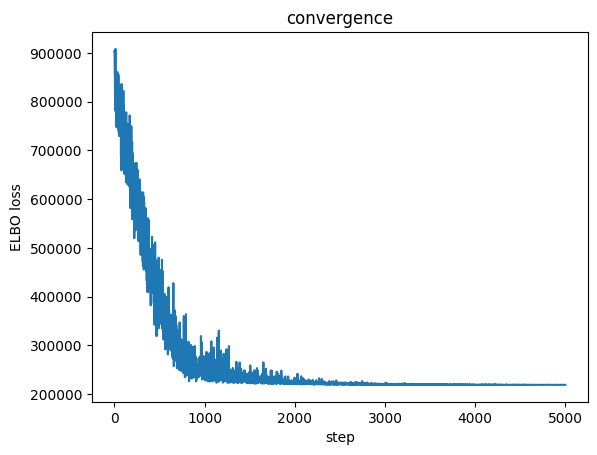

In [ ]:
plt.plot(losses1)
plt.xlabel("step")
plt.ylabel("ELBO loss")
plt.title("convergence")
plt.show()

Converges well!

Access samples from the posterior

In [ ]:
predictive = Predictive(model1, guide=guide1, num_samples=1000)
#samples = predictive(X_stress_train[:100], X_weather_train[:100], y_train[:100])
samples = predictive(X_stress_train1, X_weather_train, None)

w_samples = samples["w"].detach().numpy()     
beta_samples = samples["beta"].detach().numpy()  

print("w means:", w_samples.mean(axis=0))
print("w stds:", w_samples.std(axis=0))
print("beta means:", beta_samples.mean(axis=0))
print("beta stds:", beta_samples.std(axis=0))

w means: [[-0.63772535  0.38931262 -0.29128093  0.20935991 -0.21895453 -0.23414472
   0.22596973 -0.08004841 -0.3344674  -0.58895564 -0.24894375 -0.19054134
  -0.07308269 -0.00927946  0.04406508 -0.22772339  0.32408026 -0.02716331]]
w stds: [[0.00339559 0.00618878 0.00228014 0.00359219 0.0039686  0.00303369
  0.00273996 0.00319142 0.00366667 0.00556011 0.00325663 0.00329857
  0.00276897 0.00255354 0.00285977 0.00312194 0.00245371 0.00186606]]
beta means: [[ 0.19143991  0.10476103 -0.20040274]]
beta stds: [[0.00466282 0.00634972 0.01392748]]


This is also good to access samples but also obs bc it gioe sthrough the whole model, it is too much

In [56]:
# # use a small subset just to get parameter samples

# # draw 1000 samples of w and beta from the guide
# predictive = Predictive(model, guide=guide, num_samples=1000)
# samples = predictive(X_stress_train[:100], X_weather_train[:100], y_train[:100])

# w_samples = samples["w"].detach()      
# beta_samples = samples["beta"].detach()  

# print("Stress weights (airport_size, concurrent, carrier):", w_samples.mean(dim=0))
# print("Stress uncertainty:", w_samples.std(dim=0))
# print("Delay weights (rain, wind, stress):", beta_samples.mean(dim=0))
# print("Delay uncertainty:", beta_samples.std(dim=0))

Plot posteriors using seaborn

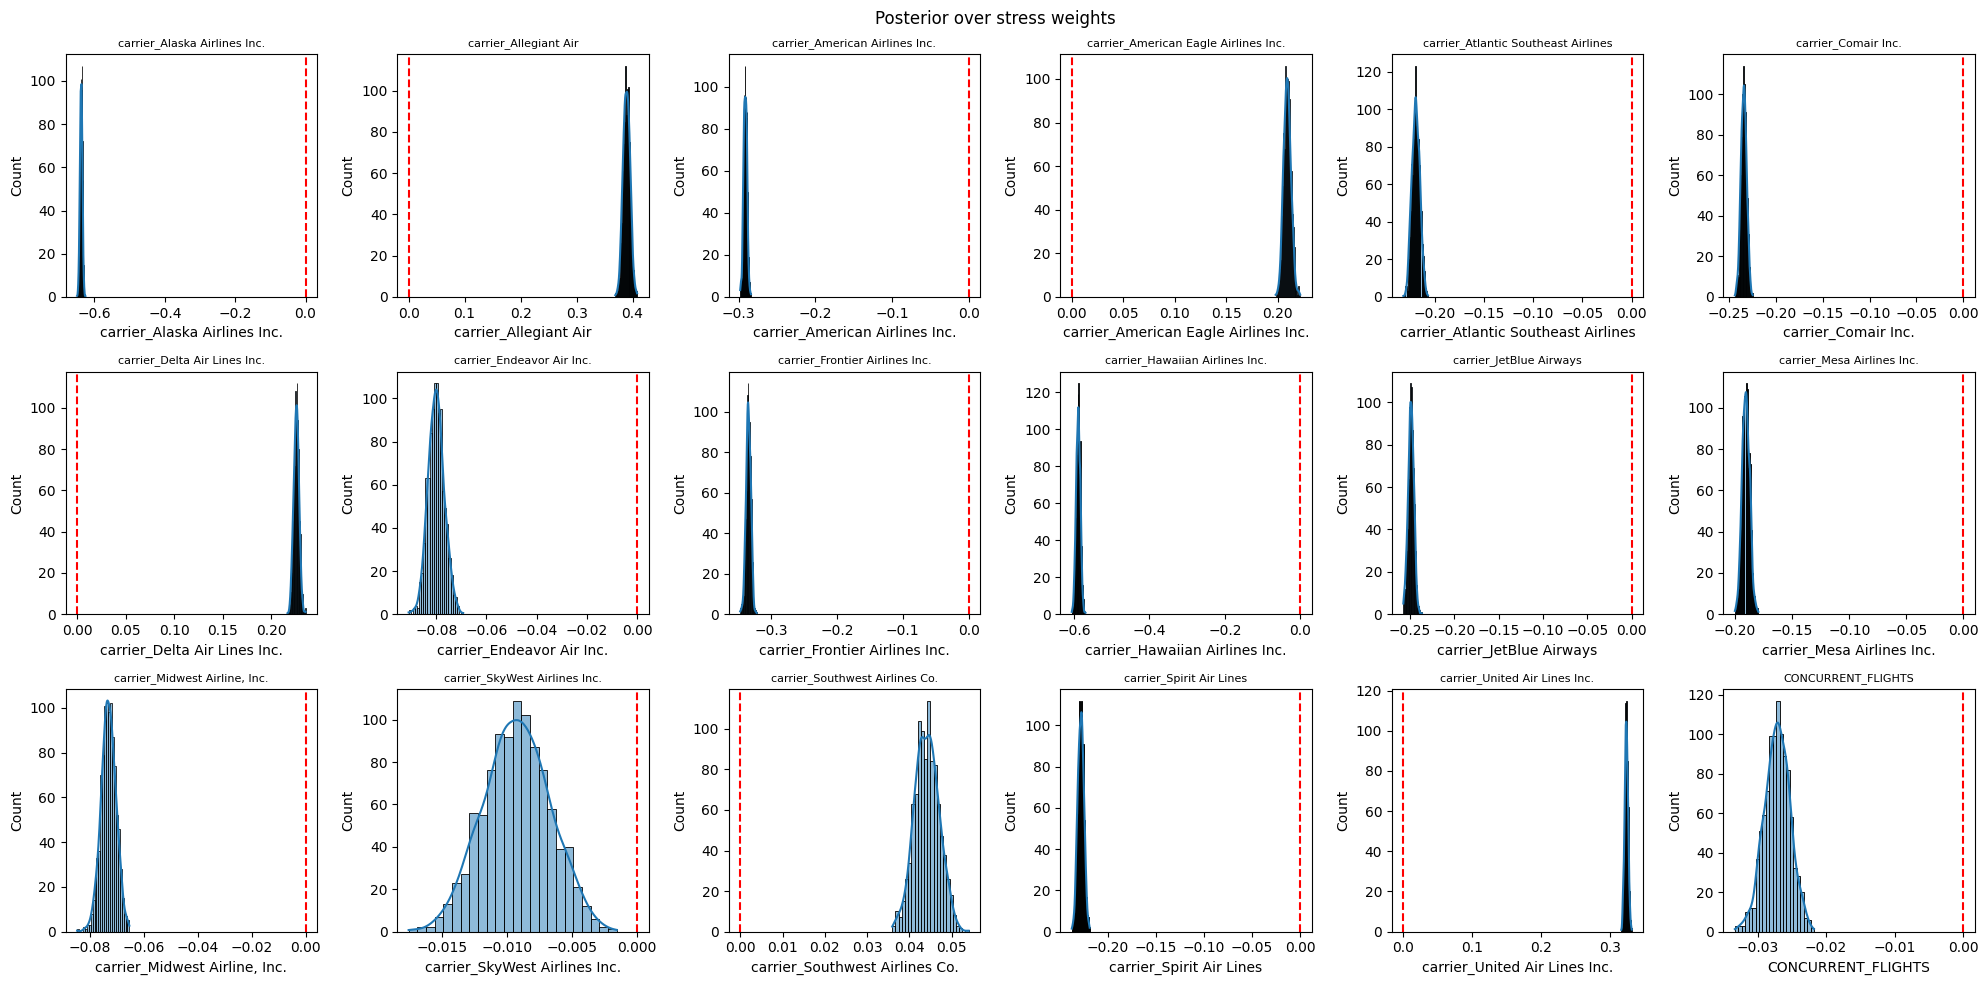

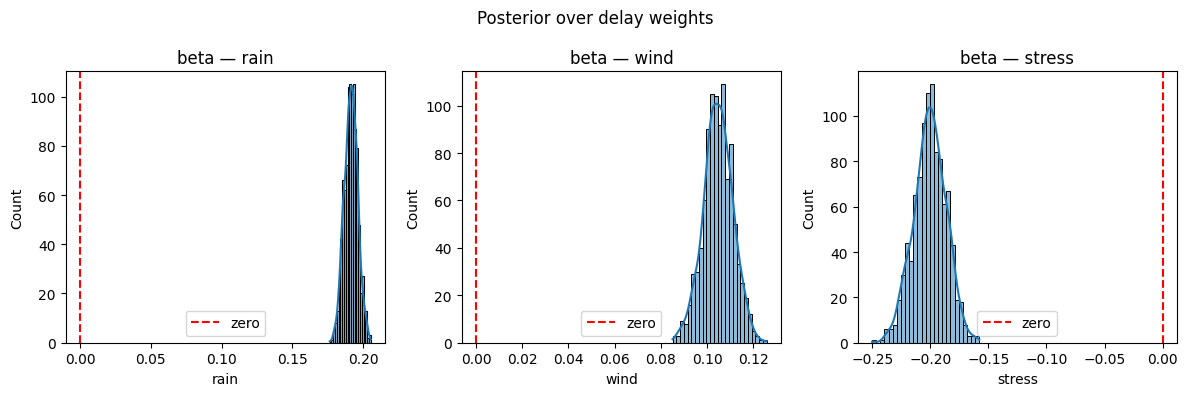

In [ ]:
w_samples = samples["w"].detach().squeeze(1).numpy()     
beta_samples = samples["beta"].detach().squeeze(1).numpy()  
bias_samples = samples["bias"].detach().squeeze(1).numpy() 

stress_cols1 = carrier_columns + ["CONCURRENT_FLIGHTS"]
w_df = pd.DataFrame(w_samples, columns=stress_cols1)  

fig, axes = plt.subplots(3, 6, figsize=(20, 10)) 
axes = axes.flatten()
for i, col in enumerate(w_df.columns):
    sns.histplot(w_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
plt.suptitle("Posterior over stress weights")
plt.tight_layout()
plt.show()

beta_df = pd.DataFrame(beta_samples, columns=["rain", "wind", "stress"])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, col in enumerate(beta_df.columns):
    sns.histplot(beta_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--", label="zero")
    axes[i].set_title(f"beta — {col}")
    axes[i].legend()
plt.suptitle("Posterior over delay weights")
plt.tight_layout()
plt.show()

Posterior predictive check

For the train data, we use the parameters we learned to see if the model would predict the delay correctly

In [42]:
# get bias samples
bias_samples = samples["bias"].detach().squeeze(1).numpy()

stress_train = X_stress_train1.numpy() @ w_samples.mean(axis=0)

logits_train = (beta_samples.mean(axis=0)[0] * X_weather_train.numpy()[:,0] +
                beta_samples.mean(axis=0)[1] * X_weather_train.numpy()[:,1] +
                beta_samples.mean(axis=0)[2] * stress_train +
                bias_samples.mean())  # add bias

p_train = torch.sigmoid(torch.tensor(logits_train)).numpy()
y_fake = np.random.binomial(1, p_train)

print("Real delay rate:", y_train.numpy().mean())
print("Fake delay rate:", y_fake.mean())

Real delay rate: 0.1891448
Fake delay rate: 0.18897968888282252


In [43]:
bias_samples = samples["bias"].detach().squeeze(1).numpy()
print("bias mean:", bias_samples.mean())
print("bias std:", bias_samples.std())

bias mean: -1.4801638
bias std: 0.006404315


## Testing

In [44]:
CHUNK = 10000
p_mean_list = []
p_std_list  = []

for i in range(0, len(X_stress_test1), CHUNK):
    X_s = X_stress_test1[i:i+CHUNK].numpy()
    X_w = X_weather_test[i:i+CHUNK].numpy()

    stress = X_s @ w_samples.mean(axis=0)
    logits = (beta_samples.mean(axis=0)[0] * X_w[:,0] +
               beta_samples.mean(axis=0)[1] * X_w[:,1] +
               beta_samples.mean(axis=0)[2] * stress +
               bias_samples.mean())

    p = torch.sigmoid(torch.tensor(logits)).numpy()
    p_mean_list.append(p)

p_mean = np.concatenate(p_mean_list)
y_pred = (p_mean > 0.5).astype(float)

In [45]:
y_test_np = y_test.numpy()

print("=== Test Evaluation ===")
print(f"Real delay rate:      {y_test_np.mean():.4f}")
print(f"Predicted delay rate: {y_pred.mean():.4f}")
print(f"Accuracy:  {accuracy_score(y_test_np, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_np, p_mean):.4f}")
print(classification_report(y_test_np, y_pred))

=== Test Evaluation ===
Real delay rate:      0.1891
Predicted delay rate: 0.0009
Accuracy:  0.8107
AUC-ROC:   0.5685
              precision    recall  f1-score   support

         0.0       0.81      1.00      0.90   1578509
         1.0       0.42      0.00      0.00    368210

    accuracy                           0.81   1946719
   macro avg       0.61      0.50      0.45   1946719
weighted avg       0.74      0.81      0.73   1946719



In [46]:
print("p_mean min:", p_mean.min())
print("p_mean max:", p_mean.max())
print("p_mean mean:", p_mean.mean())
print("p_mean percentiles:", np.percentile(p_mean, [25, 50, 75, 90, 95, 99]))

p_mean min: 0.13263023
p_mean max: 0.79953074
p_mean mean: 0.18905099
p_mean percentiles: [0.16600379 0.17788079 0.19561292 0.22966224 0.26855795 0.36910662]


# 3. Second Model

Variables:
- Rain
- Wind
- Carrier (stress)
- Concurrent flights (stress)
- Departure time block
- Segment number (stress) <br>

Delay as linear combo of rain, wind, departure time block and stress <br>
Stress as linear combo of carrier, concurrent flights and segment number

## Training phase

In [ ]:
def model2(X_stress, X_weather, X_dept, y):

    n_stress = X_stress.shape[1] 
    n_weather = X_weather.shape[1]
    n_dpt = X_dept.shape[1] 
    n_delay = n_weather + n_dpt + 1

    # priors on stress parameters
    w = pyro.sample("w", dist.Normal(torch.zeros(n_stress), torch.ones(n_stress)).to_event(1))
    sigma_stress = pyro.sample("sigma_stress", dist.HalfNormal(1.0))
    
    # priors on delay parameters
    beta = pyro.sample("beta", dist.Normal(torch.zeros(n_delay), torch.ones(n_delay)).to_event(1))
    bias = pyro.sample("bias", dist.Normal(0., 1.))
    
    with pyro.plate("flights", X_stress.shape[0]):

        mu_stress = torch.matmul(X_stress, w.T if w.dim() > 1 else w.unsqueeze(-1)).squeeze(-1)
        stress = pyro.sample("stress", dist.Normal(mu_stress, sigma_stress))
        
        logits = ((X_weather * beta[..., 0:n_weather]).sum(dim=-1) + (X_dept * beta[..., n_weather:n_delay-1]).sum(dim=-1) + beta[..., -1] * stress + bias)
        
        obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    return obs

In [ ]:
# clear any previous run
pyro.clear_param_store()

# vi approximation of posterior
# AutoDiagonalNormal for mean field aprox
# torch.manual_seed(42)
# pyro.set_rng_seed(42)
guide2 = AutoDiagonalNormal(model2)

# setup
adam_params = {"lr": 0.001}
optimizer = ClippedAdam(adam_params)
elbo = Trace_ELBO(num_particles=1)
svi = SVI(model2, guide2, optimizer, loss=elbo)

n_steps = 5000

# training loop
losses2 = []
for step in range(n_steps):
    # loss is -ELBO
    loss = svi.step(X_stress_train2, X_weather_train, X_dept_train, y_train)
    losses2.append(loss)
    if step % 1000 == 0:
        print(f"[{step}] loss (neg ELBO): {loss:.1f}")

[0] loss (neg ELBO): 1290405.3
[1000] loss (neg ELBO): 309185.8
[2000] loss (neg ELBO): 216132.9
[3000] loss (neg ELBO): 214351.9
[4000] loss (neg ELBO): 212042.6


Plot to see if it converges

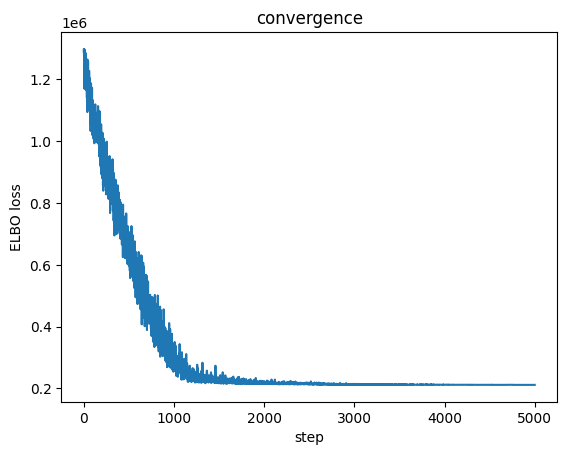

In [ ]:
plt.plot(losses2)
plt.xlabel("step")
plt.ylabel("ELBO loss")
plt.title("convergence")
plt.show()

Access samples from the posterior

In [ ]:
from pyro.infer import Predictive

predictive = Predictive(model2, guide=guide2, num_samples=1000)
#samples = predictive(X_stress_train[:100], X_weather_train[:100], y_train[:100])
samples = predictive(X_stress_train2, X_weather_train, X_dept_train, None)

w_samples = samples["w"].detach().numpy()     
beta_samples = samples["beta"].detach().numpy()  

print("w means:", w_samples.mean(axis=0))
print("w stds:", w_samples.std(axis=0))
print("beta means:", beta_samples.mean(axis=0))
print("beta stds:", beta_samples.std(axis=0))

w means: [[-0.1151856  -0.2996745  -0.18803959 -0.19698334 -0.572813    0.3762519
  -0.04849385 -0.13669834 -0.14125045 -0.32673985  0.18224718  0.16981927
  -0.533511    0.47768205 -0.16668846 -0.14749771 -0.23064256  0.3737194 ]]
w stds: [[0.00696327 0.00294514 0.00413233 0.00468311 0.00392475 0.00275657
  0.0037966  0.00449675 0.00737631 0.00369626 0.00387726 0.0034275
  0.00308334 0.00295491 0.00365358 0.00318795 0.00187309 0.00176609]]
beta means: [[ 0.2047711   0.101062   -0.95680857 -0.6328096  -0.41128215 -0.198677
  -0.06631919  0.02979982  0.16338481  0.28326416  0.41813445  0.480576
   0.57457465  0.6414984   0.7020095   0.76699024  0.7044698   0.72414047
   0.5610749   0.3755596  -0.05018805]]
beta stds: [[0.00511165 0.00592531 0.03102604 0.02839843 0.02311748 0.02428908
  0.02126595 0.0227714  0.02252189 0.02137981 0.02044064 0.020306
  0.02077287 0.01981015 0.02071749 0.01972997 0.01998856 0.02395292
  0.02517572 0.04434719 0.00900628]]


Plot posteriors with seaborn

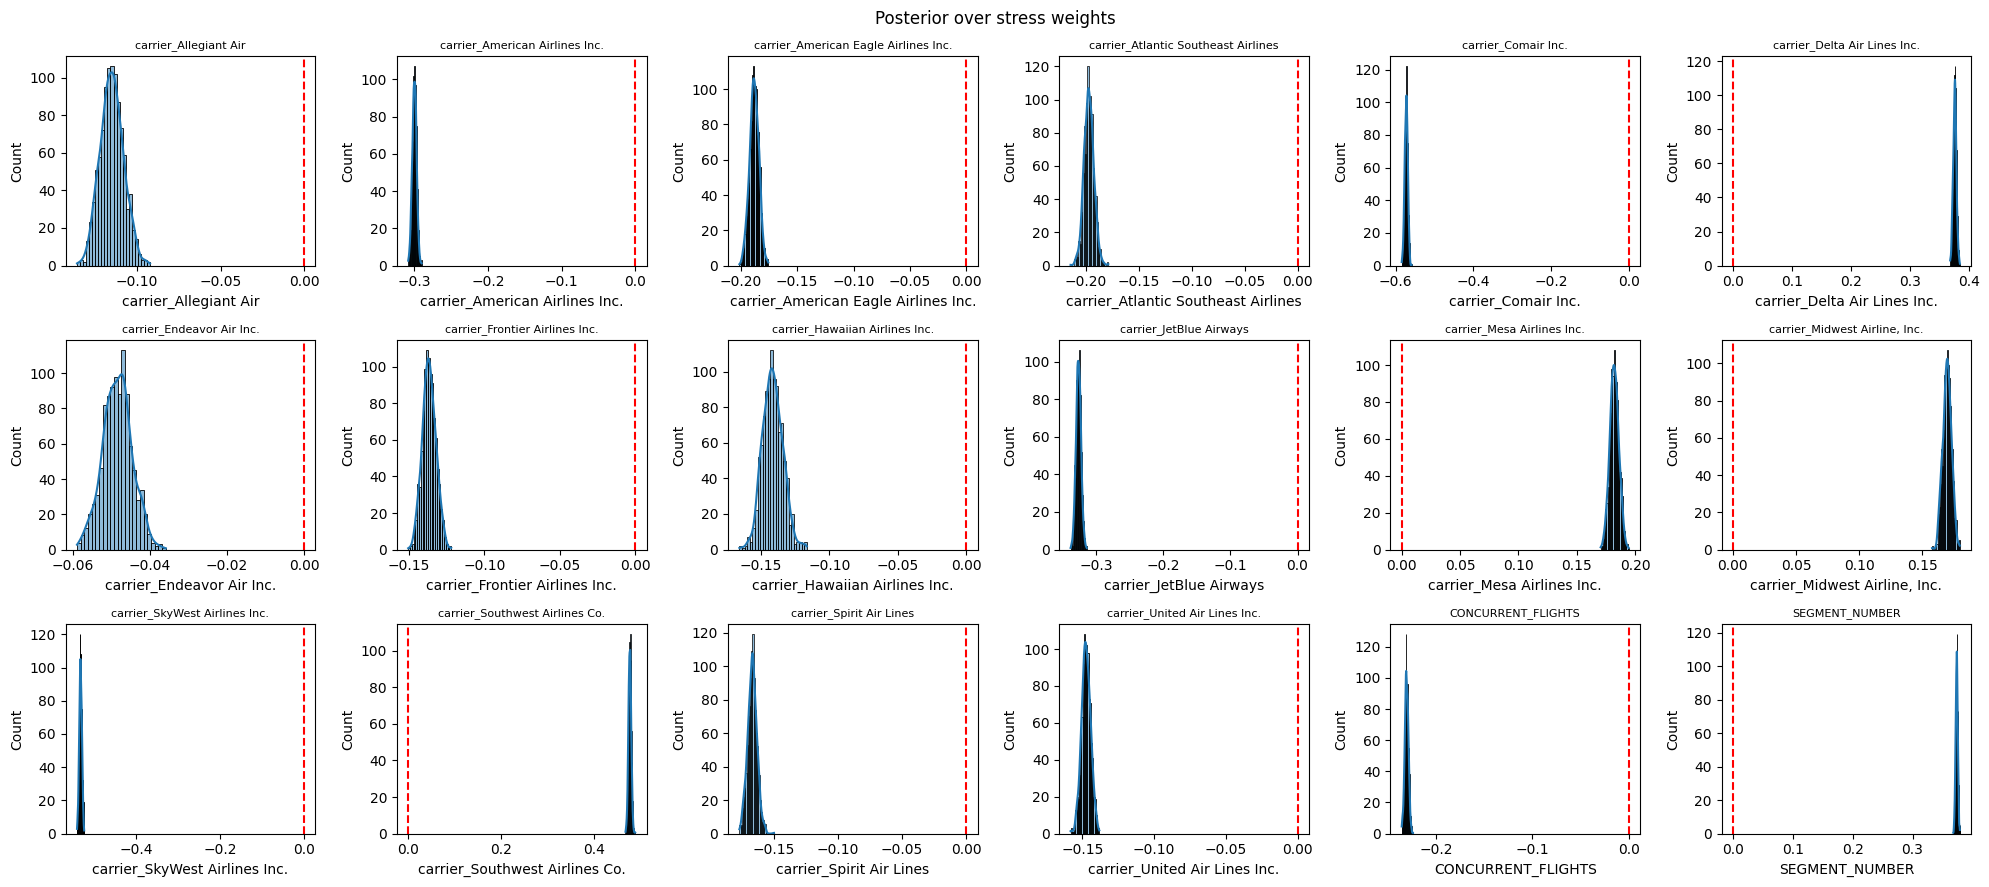

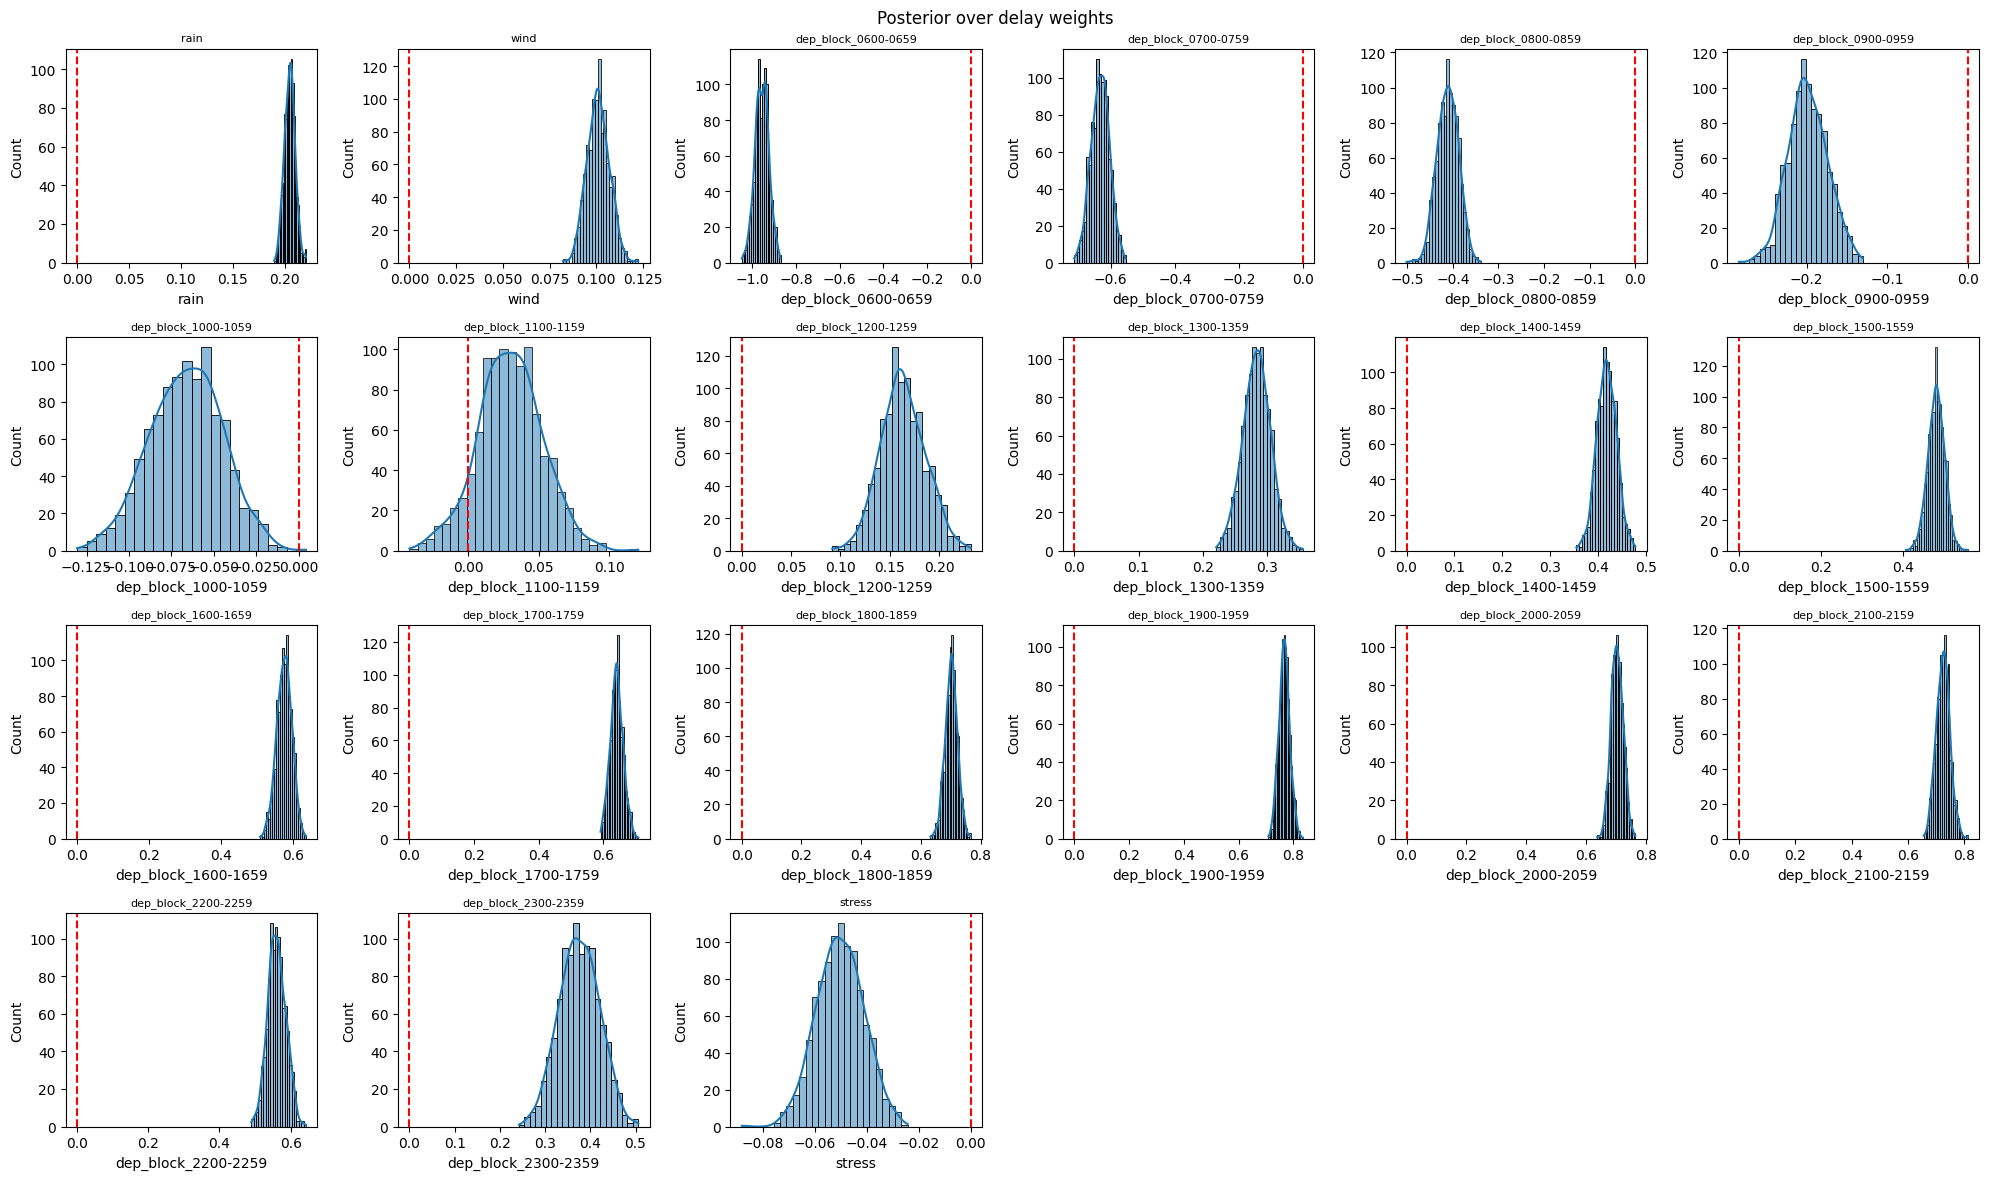

In [78]:
w_samples = samples["w"].detach().squeeze(1).numpy()     
beta_samples = samples["beta"].detach().squeeze(1).numpy()  
bias_samples = samples["bias"].detach().squeeze(1).numpy() 

stress_cols2 = carrier_columns_model + ["CONCURRENT_FLIGHTS", "SEGMENT_NUMBER"]
w_df = pd.DataFrame(w_samples, columns=stress_cols2)

n_stress_cols = len(stress_cols2)
n_rows = (n_stress_cols + 5) // 6  # enough rows for 6 columns
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(w_df.columns):
    sns.histplot(w_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
# hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over stress weights")
plt.tight_layout()
plt.show()

# ── delay weights ──
# beta columns: rain, wind, dep blocks, stress
beta_cols = ["rain", "wind"] + dpt_columns_model + ["stress"]
beta_df = pd.DataFrame(beta_samples, columns=beta_cols)

n_beta_cols = len(beta_cols)
n_rows = (n_beta_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(beta_df.columns):
    sns.histplot(beta_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over delay weights")
plt.tight_layout()
plt.show()

## Testing

In [79]:
# get posterior means
w_mean    = w_samples.mean(axis=0)      # (n_stress,)
beta_mean = beta_samples.mean(axis=0)   # (n_delay,)
bias_mean = bias_samples.mean()         # scalar

n_weather = X_weather_test.shape[1]     # 2
n_dpt     = X_dept_test.shape[1]        # 19
n_delay   = n_weather + n_dpt + 1       # 22

CHUNK = 10000
p_mean_list = []

for i in range(0, len(X_stress_test2), CHUNK):
    X_s = X_stress_test2[i:i+CHUNK].numpy()
    X_w = X_weather_test[i:i+CHUNK].numpy()
    X_d = X_dept_test[i:i+CHUNK].numpy()

    stress = X_s @ w_mean

    logits = (
        (X_w * beta_mean[0:n_weather]).sum(axis=1) +
        (X_d * beta_mean[n_weather:n_delay-1]).sum(axis=1) +
        beta_mean[-1] * stress +
        bias_mean
    )

    p = torch.sigmoid(torch.tensor(logits)).numpy()
    p_mean_list.append(p)

p_mean = np.concatenate(p_mean_list)
y_pred = (p_mean > 0.5).astype(float)

In [80]:
y_test_np = y_test.numpy()

print("=== Test Evaluation ===")
print(f"Real delay rate:      {y_test_np.mean():.4f}")
print(f"Predicted delay rate: {y_pred.mean():.4f}")
print(f"Accuracy:  {accuracy_score(y_test_np, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_np, p_mean):.4f}")
print(classification_report(y_test_np, y_pred))

=== Test Evaluation ===
Real delay rate:      0.1891
Predicted delay rate: 0.0033
Accuracy:  0.8107
AUC-ROC:   0.6450
              precision    recall  f1-score   support

         0.0       0.81      1.00      0.90   1578509
         1.0       0.48      0.01      0.02    368210

    accuracy                           0.81   1946719
   macro avg       0.65      0.50      0.46   1946719
weighted avg       0.75      0.81      0.73   1946719



# 4. Third model

Variables:
- Rain
- Wind
- Carrier (stress)
- Concurrent flights (stress)
- Departure time block

Delay as linear combo of rain, wind, departure time block and stress <br>
Stress as linear combo of baseline carrier per carrier and concurrent flights

In [37]:
def model3(carrier_idx, X_concurrent, X_weather, X_dept, y):
    
    n_carriers = len(carrier_categories3)
    n_weather = X_weather.shape[1]
    n_dept = X_dept.shape[1]
    n_delay = n_weather + n_dept + 1

    # hyperpriors on carriers baseline
    mu_alpha = pyro.sample("mu_alpha", dist.Normal(0., 1.))
    sigma_alpha = pyro.sample("sigma_alpha", dist.HalfNormal(1.))

    # carrier baseline
    alpha_carrier = pyro.sample("alpha_carrier", dist.Normal(mu_alpha * torch.ones(n_carriers), sigma_alpha * torch.ones(n_carriers)).to_event(1))

    # stress parameters
    w_concurrent = pyro.sample("w_concurrent", dist.Normal(0., 1.))
    sigma_stress = pyro.sample("sigma_stress", dist.HalfNormal(1.0))

    # delay parameters
    beta = pyro.sample("beta", dist.Normal(torch.zeros(n_delay), torch.ones(n_delay)).to_event(1))
    bias = pyro.sample("bias", dist.Normal(0., 1.))

    with pyro.plate("flights", X_weather.shape[0]):
        
        mu_stress = alpha_carrier[..., carrier_idx] + w_concurrent * X_concurrent
        stress = pyro.sample("stress", dist.Normal(mu_stress, sigma_stress))

        logits = ((X_weather * beta[..., 0:n_weather]).sum(dim=-1) + (X_dept * beta[..., n_weather:n_delay-1]).sum(dim=-1) + beta[..., -1] * stress + bias)

        obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    return obs

In [ ]:
# clear any previous run
pyro.clear_param_store()

# vi approximation of posterior
# AutoDiagonalNormal for mean field aprox
# torch.manual_seed(42)
# pyro.set_rng_seed(42)
guide3 = AutoDiagonalNormal(model3)

# setup
adam_params = {"lr": 0.001}
optimizer = ClippedAdam(adam_params)
elbo = Trace_ELBO(num_particles=1)
svi = SVI(model3, guide3, optimizer, loss=elbo)

n_steps = 5000

# training loop
losses3 = []
for step in range(n_steps):
    # loss is -ELBO
    loss = svi.step(carrier_idx_train, X_conc_train, X_weather_train, X_dept_train, y_train)
    losses3.append(loss)
    if step % 1000 == 0:
        print(f"[{step}] loss (neg ELBO): {loss:.1f}")

[0] loss (neg ELBO): 955976.2
[1000] loss (neg ELBO): 232451.5
[2000] loss (neg ELBO): 215123.7
[3000] loss (neg ELBO): 213155.1
[4000] loss (neg ELBO): 211911.6


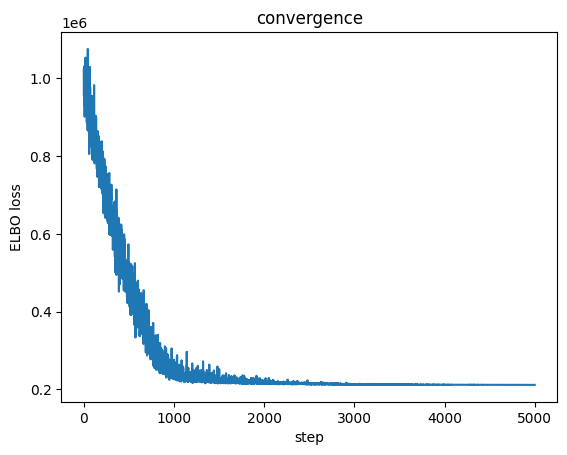

In [ ]:
plt.plot(losses3)
plt.xlabel("step")
plt.ylabel("ELBO loss")
plt.title("convergence")
plt.show()

see posteriors

In [ ]:
predictive3 = Predictive(model3, guide=guide3, num_samples=1000)
samples3 = predictive3(carrier_idx_train, X_conc_train, X_weather_train, X_dept_train, None)

# global parameters
alpha_carrier_samples = samples3["alpha_carrier"].detach().squeeze(1).numpy()  # (1000, 17)
w_concurrent_samples  = samples3["w_concurrent"].detach().squeeze(1).numpy()   # (1000,)
mu_alpha_samples      = samples3["mu_alpha"].detach().squeeze(1).numpy()        # (1000,)
sigma_alpha_samples   = samples3["sigma_alpha"].detach().squeeze(1).numpy()     # (1000,)
beta_samples          = samples3["beta"].detach().squeeze(1).numpy()            # (1000, 21)
bias_samples          = samples3["bias"].detach().squeeze(1).numpy()            # (1000,)

# print summaries
print("mu_alpha mean:", mu_alpha_samples.mean())
print("sigma_alpha mean:", sigma_alpha_samples.mean())
print("\nCarrier baselines (alpha_carrier):")
for i, carrier in enumerate(carrier_categories3):
    print(f"  {carrier}: {alpha_carrier_samples[:, i].mean():.4f} ± {alpha_carrier_samples[:, i].std():.4f}")

print("\nw_concurrent mean:", w_concurrent_samples.mean())
print("w_concurrent std:", w_concurrent_samples.std())

print("\nbeta means:", beta_samples.mean(axis=0))
print("beta stds:", beta_samples.std(axis=0))

mu_alpha mean: 0.67987263
sigma_alpha mean: 0.34888065

Carrier baselines (alpha_carrier):
  Alaska Airlines Inc.: 0.8840 ± 0.0035
  Allegiant Air: 0.3460 ± 0.0066
  American Airlines Inc.: 0.7528 ± 0.0024
  American Eagle Airlines Inc.: 0.4044 ± 0.0038
  Atlantic Southeast Airlines: 0.2138 ± 0.0042
  Comair Inc.: 0.9088 ± 0.0033
  Delta Air Lines Inc.: 0.6917 ± 0.0028
  Endeavor Air Inc.: 0.9755 ± 0.0034
  Frontier Airlines Inc.: 0.9612 ± 0.0039
  Hawaiian Airlines Inc.: 0.4947 ± 0.0059
  JetBlue Airways: 0.6562 ± 0.0036
  Mesa Airlines Inc.: 0.9252 ± 0.0035
  Midwest Airline, Inc.: 0.1857 ± 0.0030
  SkyWest Airlines Inc.: 1.3615 ± 0.0026
  Southwest Airlines Co.: 0.2596 ± 0.0028
  Spirit Air Lines: 0.9624 ± 0.0034
  United Air Lines Inc.: 0.7387 ± 0.0024

w_concurrent mean: 0.16833545
w_concurrent std: 0.0017603975

beta means: [ 0.2053937   0.1062243  -0.94584036 -0.6043894  -0.37925446 -0.17206022
 -0.04810567  0.04408913  0.16390532  0.28154007  0.42025962  0.48168233
  0.5677001 

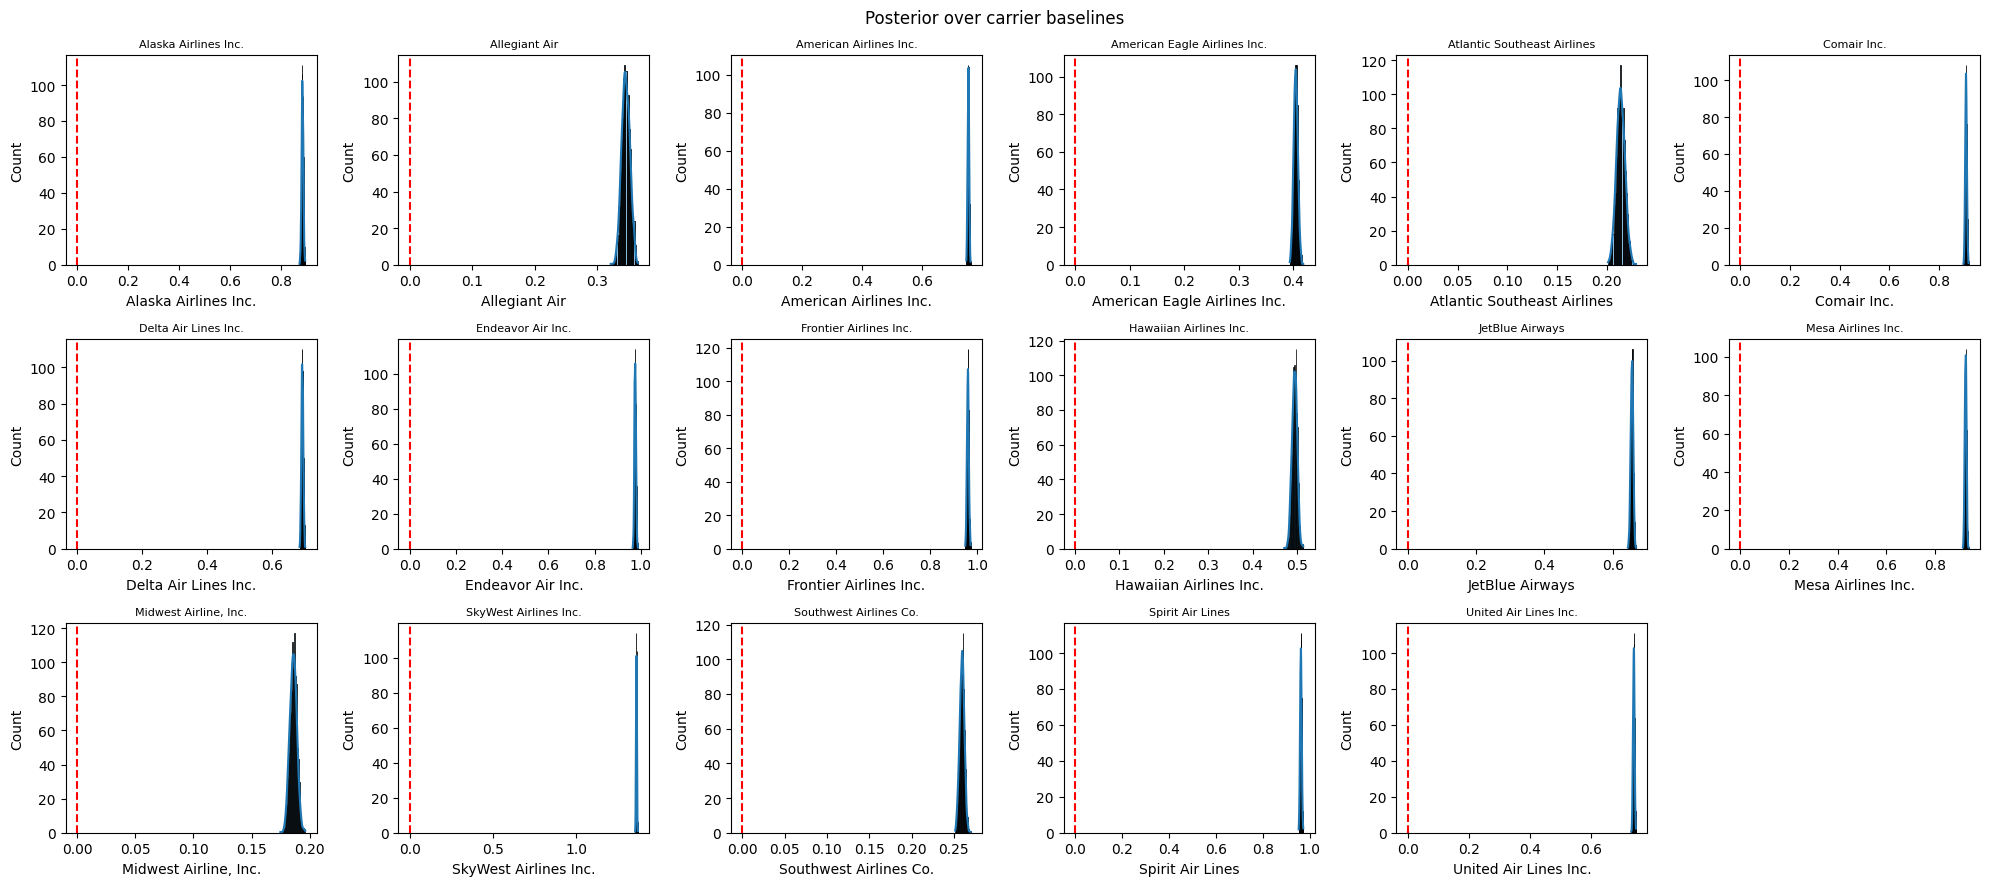

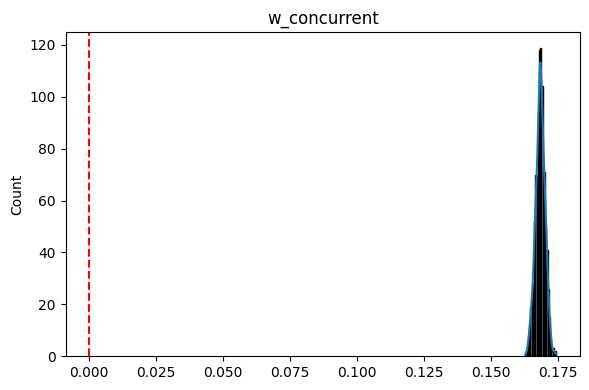

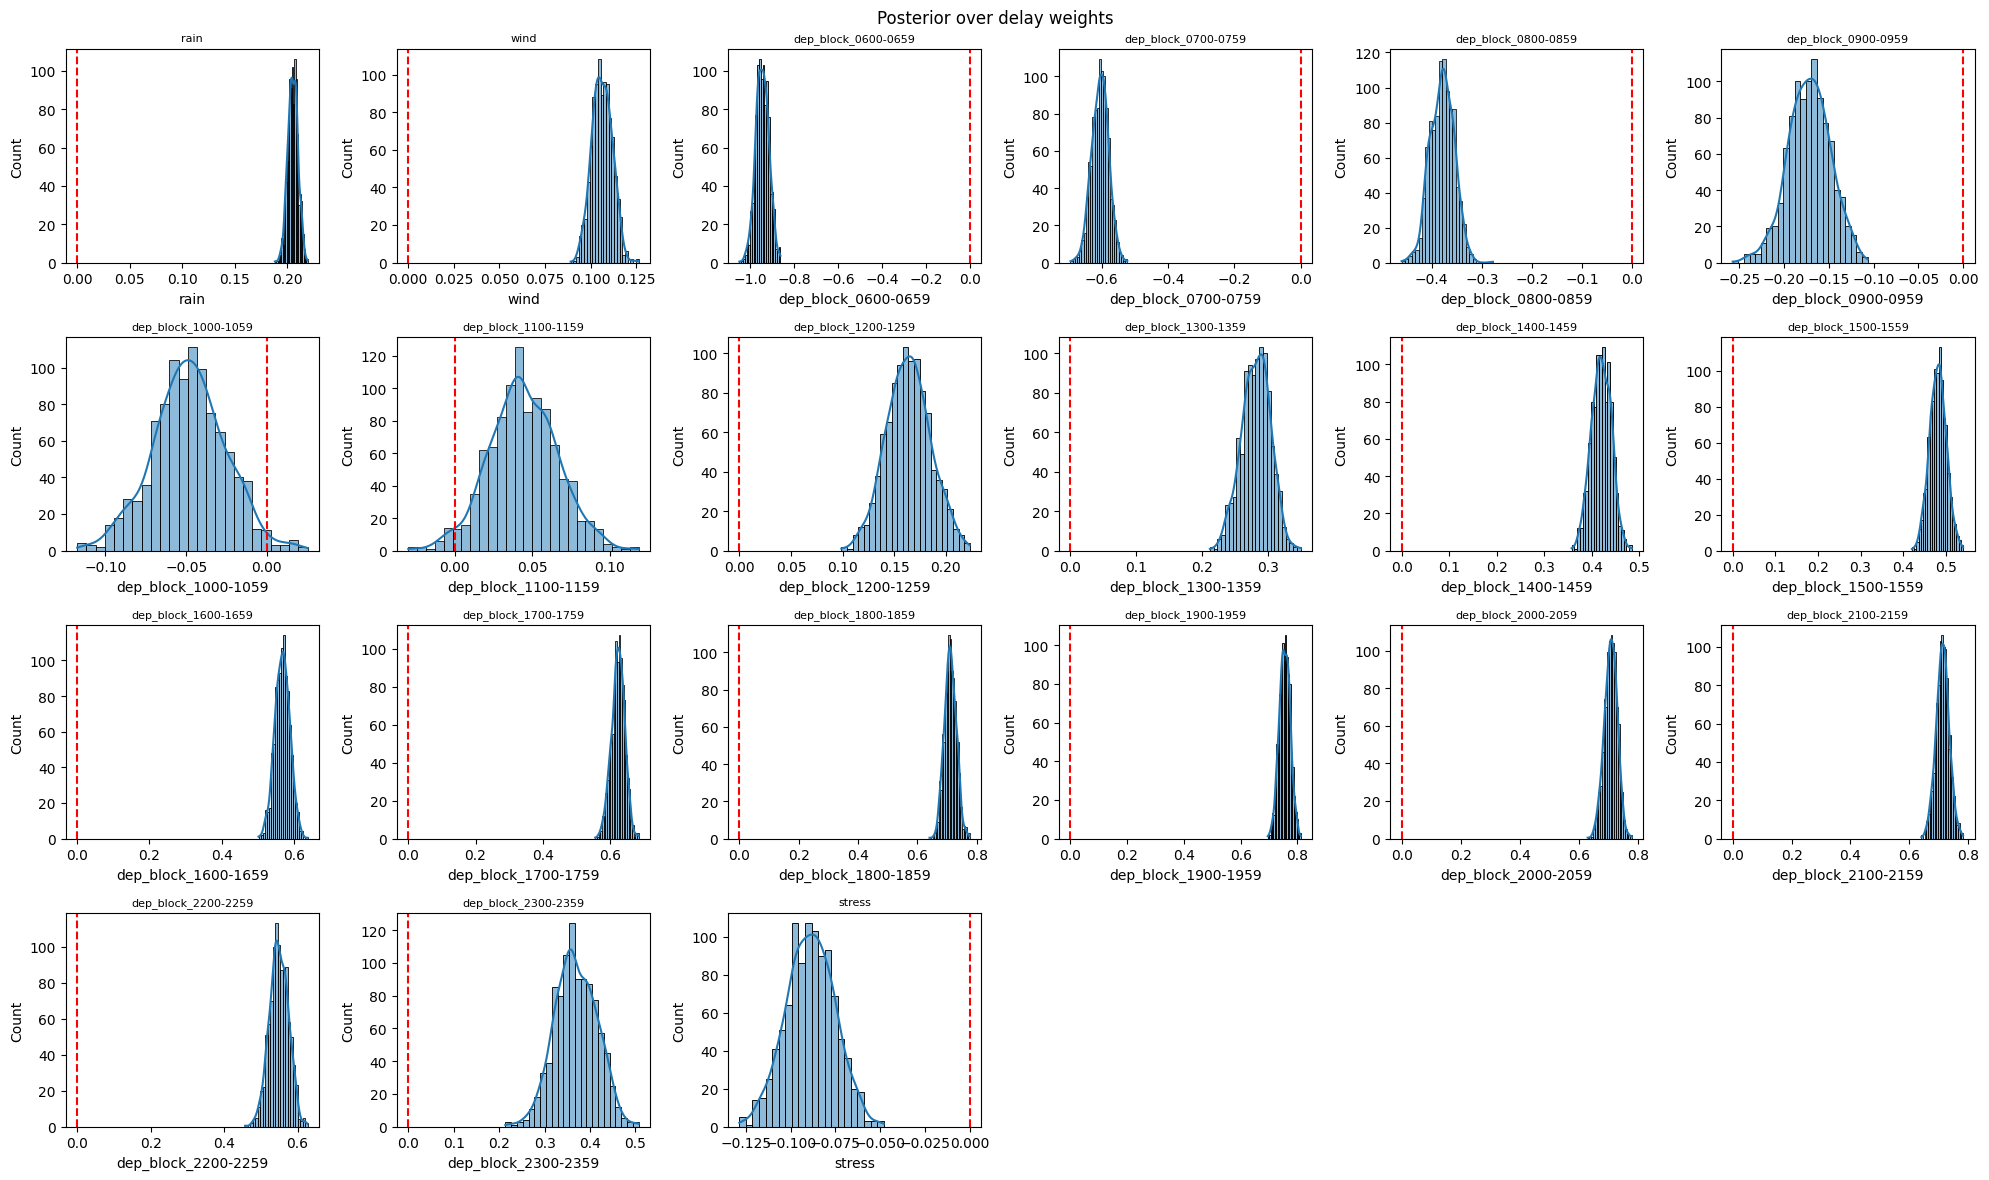

In [42]:
# ── carrier baselines ──
alpha_df = pd.DataFrame(alpha_carrier_samples, columns=carrier_categories3.tolist())

n_cols = len(carrier_categories3)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(alpha_df.columns):
    sns.histplot(alpha_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over carrier baselines")
plt.tight_layout()
plt.show()

# ── w_concurrent ──
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.histplot(w_concurrent_samples, ax=ax, kde=True)
ax.axvline(0, color="red", linestyle="--")
ax.set_title("w_concurrent")
plt.tight_layout()
plt.show()

# ── delay weights ──
beta_cols = ["rain", "wind"] + dpt_columns_model + ["stress"]
beta_df = pd.DataFrame(beta_samples, columns=beta_cols)

n_beta_cols = len(beta_cols)
n_rows = (n_beta_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(beta_df.columns):
    sns.histplot(beta_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over delay weights")
plt.tight_layout()
plt.show()

### Testing

In [43]:
# get posterior means
alpha_carrier_mean = alpha_carrier_samples.mean(axis=0)  # (17,)
w_concurrent_mean  = w_concurrent_samples.mean()          # scalar
beta_mean          = beta_samples.mean(axis=0)            # (21,)
bias_mean          = bias_samples.mean()                  # scalar

n_weather = X_weather_test.shape[1]   # 2
n_dpt     = X_dept_test.shape[1]      # 18
n_delay   = n_weather + n_dpt + 1     # 21

CHUNK = 10000
p_mean_list = []

for i in range(0, len(X_weather_test), CHUNK):
    X_w = X_weather_test[i:i+CHUNK].numpy()
    X_d = X_dept_test[i:i+CHUNK].numpy()
    c_idx = carrier_idx_test[i:i+CHUNK].numpy()
    x_conc = X_conc_test[i:i+CHUNK].numpy()

    # compute stress using carrier baseline + concurrent flights
    stress = alpha_carrier_mean[c_idx] + w_concurrent_mean * x_conc

    logits = (
        (X_w * beta_mean[0:n_weather]).sum(axis=1) +
        (X_d * beta_mean[n_weather:n_delay-1]).sum(axis=1) +
        beta_mean[-1] * stress +
        bias_mean
    )

    p = torch.sigmoid(torch.tensor(logits, dtype=torch.float32)).numpy()
    p_mean_list.append(p)

p_mean = np.concatenate(p_mean_list)
y_pred = (p_mean > 0.5).astype(float)

In [44]:
y_test_np = y_test.numpy()

print("=== Test Evaluation ===")
print(f"Real delay rate:      {y_test_np.mean():.4f}")
print(f"Predicted delay rate: {y_pred.mean():.4f}")
print(f"Accuracy:  {accuracy_score(y_test_np, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_np, p_mean):.4f}")
print(classification_report(y_test_np, y_pred))

=== Test Evaluation ===
Real delay rate:      0.1891
Predicted delay rate: 0.0034
Accuracy:  0.8108
AUC-ROC:   0.6459
              precision    recall  f1-score   support

         0.0       0.81      1.00      0.90   1578509
         1.0       0.49      0.01      0.02    368210

    accuracy                           0.81   1946719
   macro avg       0.65      0.50      0.46   1946719
weighted avg       0.75      0.81      0.73   1946719



# 5. Fourth model

In [98]:
def model4(carrier_idx, dep_block_idx, X_concurrent, X_weather, y):
    
    n_carriers = len(carrier_categories3)
    n_depblocks = len(depblock_categories)

    # hyperpriors on carrier baselines
    mu_carrier = pyro.sample("mu_alpha", dist.Normal(0., 1.))
    sigma_carrier = pyro.sample("sigma_alpha", dist.HalfNormal(1.))

    # hyperpriors on departure block baselines
    mu_dpt = pyro.sample("mu_gamma", dist.Normal(0., 1.))
    sigma_dpt = pyro.sample("sigma_gamma", dist.HalfNormal(1.))

    # carrier baselines
    carrier_baseline = pyro.sample("alpha_carrier", dist.Normal(mu_carrier * torch.ones(n_carriers), sigma_carrier * torch.ones(n_carriers)).to_event(1))

    # departure block baselines
    depblock_baseline = pyro.sample("gamma_depblock", dist.Normal(mu_dpt * torch.ones(n_depblocks), sigma_dpt * torch.ones(n_depblocks)).to_event(1))

    w_concurrent = pyro.sample("w_concurrent", dist.Normal(0., 1.))
    sigma_stress = pyro.sample("sigma_stress", dist.HalfNormal(1.0))

    beta_rain = pyro.sample("beta_rain", dist.Normal(0., 1.))
    beta_wind = pyro.sample("beta_wind", dist.Normal(0., 1.))
    beta_stress = pyro.sample("beta_stress", dist.Normal(0., 1.))
    bias = pyro.sample("bias", dist.Normal(0., 1.))

    with pyro.plate("flights", X_weather.shape[0]):
        mu_stress = (carrier_baseline[..., carrier_idx] + depblock_baseline[..., dep_block_idx] + w_concurrent * X_concurrent)
        stress = pyro.sample("stress", dist.Normal(mu_stress, sigma_stress))

        logits = (beta_rain   * X_weather[:, 0] + beta_wind   * X_weather[:, 1] + beta_stress * stress + bias)

        obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    return obs

In [99]:
# clear any previous run
pyro.clear_param_store()

# vi approximation of posterior
# AutoDiagonalNormal for mean field aprox
# torch.manual_seed(42)
# pyro.set_rng_seed(42)
guide4 = AutoDiagonalNormal(model4)

# setup
adam_params = {"lr": 0.001}
optimizer = ClippedAdam(adam_params)
elbo = Trace_ELBO(num_particles=1)
svi = SVI(model4, guide4, optimizer, loss=elbo)

n_steps = 5000

# training loop
losses4 = []
for step in range(n_steps):
    # loss is -ELBO
    loss = svi.step(carrier_idx_train, dep_block_idx_train, X_conc_train, X_weather_train, y_train)
    losses4.append(loss)
    if step % 1000 == 0:
        print(f"[{step}] loss (neg ELBO): {loss:.1f}")

[0] loss (neg ELBO): 910399.5
[1000] loss (neg ELBO): 261325.6
[2000] loss (neg ELBO): 225713.2
[3000] loss (neg ELBO): 220251.2
[4000] loss (neg ELBO): 218231.4


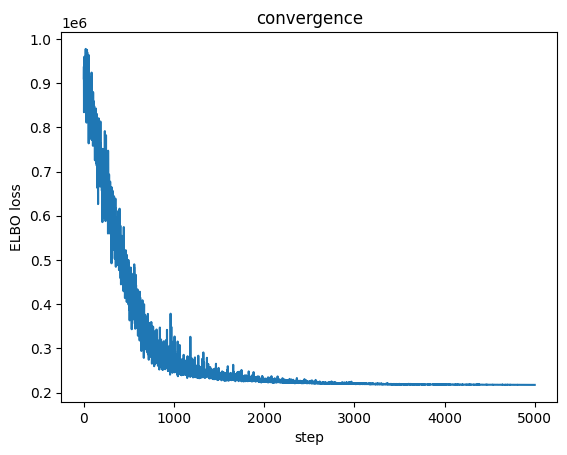

In [100]:
plt.plot(losses4)
plt.xlabel("step")
plt.ylabel("ELBO loss")
plt.title("convergence")
plt.show()

In [101]:
predictive4 = Predictive(model4, guide=guide4, num_samples=1000)
samples4 = predictive4(carrier_idx_train, dep_block_idx_train, X_conc_train, X_weather_train, None)

# global parameters
alpha_carrier_samples  = samples4["alpha_carrier"].detach().squeeze(1).numpy()   # (1000, 17)
gamma_depblock_samples = samples4["gamma_depblock"].detach().squeeze(1).numpy()  # (1000, 19)
w_concurrent_samples   = samples4["w_concurrent"].detach().squeeze(1).numpy()    # (1000,)
mu_alpha_samples       = samples4["mu_alpha"].detach().squeeze(1).numpy()         # (1000,)
sigma_alpha_samples    = samples4["sigma_alpha"].detach().squeeze(1).numpy()      # (1000,)
mu_gamma_samples       = samples4["mu_gamma"].detach().squeeze(1).numpy()         # (1000,)
sigma_gamma_samples    = samples4["sigma_gamma"].detach().squeeze(1).numpy()      # (1000,)
beta_rain_samples      = samples4["beta_rain"].detach().squeeze(1).numpy()        # (1000,)
beta_wind_samples      = samples4["beta_wind"].detach().squeeze(1).numpy()        # (1000,)
beta_stress_samples    = samples4["beta_stress"].detach().squeeze(1).numpy()      # (1000,)
bias_samples           = samples4["bias"].detach().squeeze(1).numpy()             # (1000,)

# print summaries
print("=== Hyperpriors ===")
print(f"mu_alpha:    {mu_alpha_samples.mean():.4f} ± {mu_alpha_samples.std():.4f}")
print(f"sigma_alpha: {sigma_alpha_samples.mean():.4f} ± {sigma_alpha_samples.std():.4f}")
print(f"mu_gamma:    {mu_gamma_samples.mean():.4f} ± {mu_gamma_samples.std():.4f}")
print(f"sigma_gamma: {sigma_gamma_samples.mean():.4f} ± {sigma_gamma_samples.std():.4f}")

print("\n=== Carrier baselines ===")
for i, carrier in enumerate(carrier_categories3):
    print(f"  {carrier}: {alpha_carrier_samples[:, i].mean():.4f} ± {alpha_carrier_samples[:, i].std():.4f}")

print("\n=== Departure block baselines ===")
for i, block in enumerate(depblock_categories):
    print(f"  {block}: {gamma_depblock_samples[:, i].mean():.4f} ± {gamma_depblock_samples[:, i].std():.4f}")

print("\n=== Stress parameters ===")
print(f"w_concurrent: {w_concurrent_samples.mean():.4f} ± {w_concurrent_samples.std():.4f}")

print("\n=== Delay parameters ===")
print(f"beta_rain:   {beta_rain_samples.mean():.4f} ± {beta_rain_samples.std():.4f}")
print(f"beta_wind:   {beta_wind_samples.mean():.4f} ± {beta_wind_samples.std():.4f}")
print(f"beta_stress: {beta_stress_samples.mean():.4f} ± {beta_stress_samples.std():.4f}")
print(f"bias:        {bias_samples.mean():.4f} ± {bias_samples.std():.4f}")

=== Hyperpriors ===
mu_alpha:    -0.1906 ± 0.0274
sigma_alpha: 0.1199 ± 0.0209
mu_gamma:    -0.4461 ± 0.0457
sigma_gamma: 0.1885 ± 0.0308

=== Carrier baselines ===
  Alaska Airlines Inc.: 0.0203 ± 0.0038
  Allegiant Air: -0.3427 ± 0.0066
  American Airlines Inc.: -0.3219 ± 0.0028
  American Eagle Airlines Inc.: -0.2228 ± 0.0039
  Atlantic Southeast Airlines: -0.2328 ± 0.0042
  Comair Inc.: -0.2635 ± 0.0033
  Delta Air Lines Inc.: -0.0936 ± 0.0031
  Endeavor Air Inc.: -0.1421 ± 0.0037
  Frontier Airlines Inc.: -0.1884 ± 0.0043
  Hawaiian Airlines Inc.: -0.1815 ± 0.0060
  JetBlue Airways: -0.1102 ± 0.0038
  Mesa Airlines Inc.: -0.2482 ± 0.0037
  Midwest Airline, Inc.: -0.2302 ± 0.0033
  SkyWest Airlines Inc.: 0.0092 ± 0.0030
  Southwest Airlines Co.: -0.0620 ± 0.0031
  Spirit Air Lines: -0.3161 ± 0.0037
  United Air Lines Inc.: -0.3059 ± 0.0028

=== Departure block baselines ===
  0001-0559: -0.5532 ± 0.0053
  0600-0659: -0.3241 ± 0.0037
  0700-0759: -0.4090 ± 0.0031
  0800-0859: -0.296

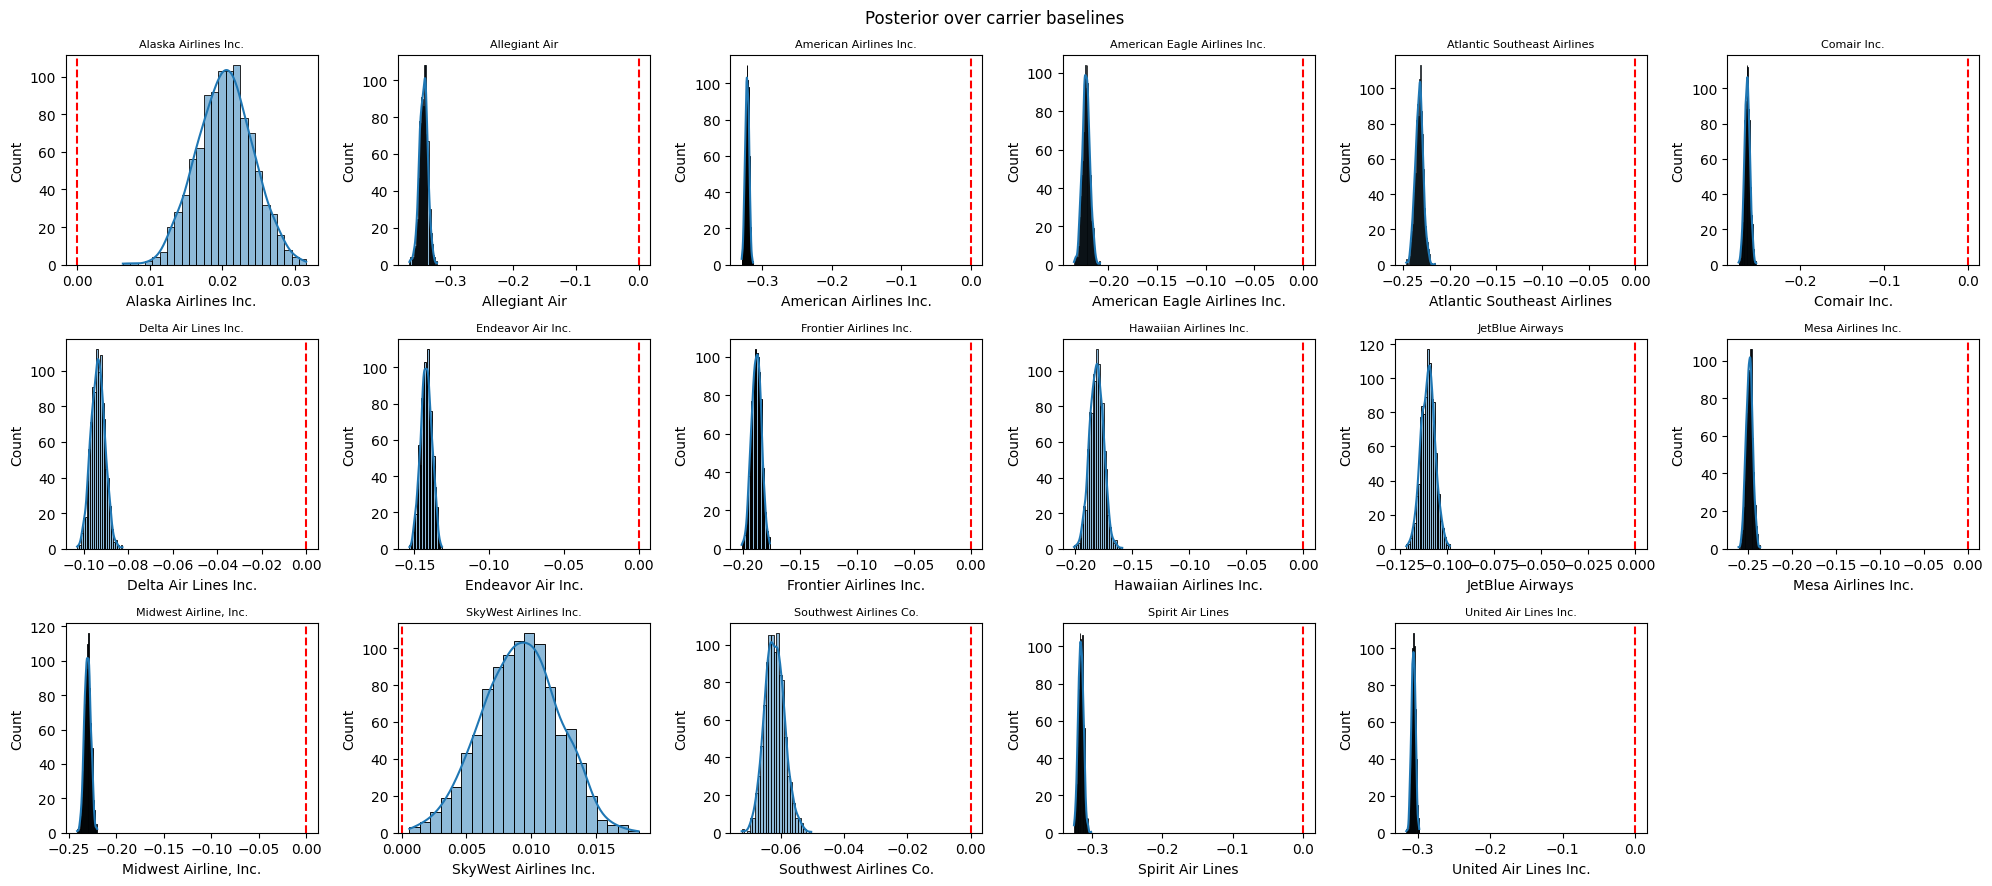

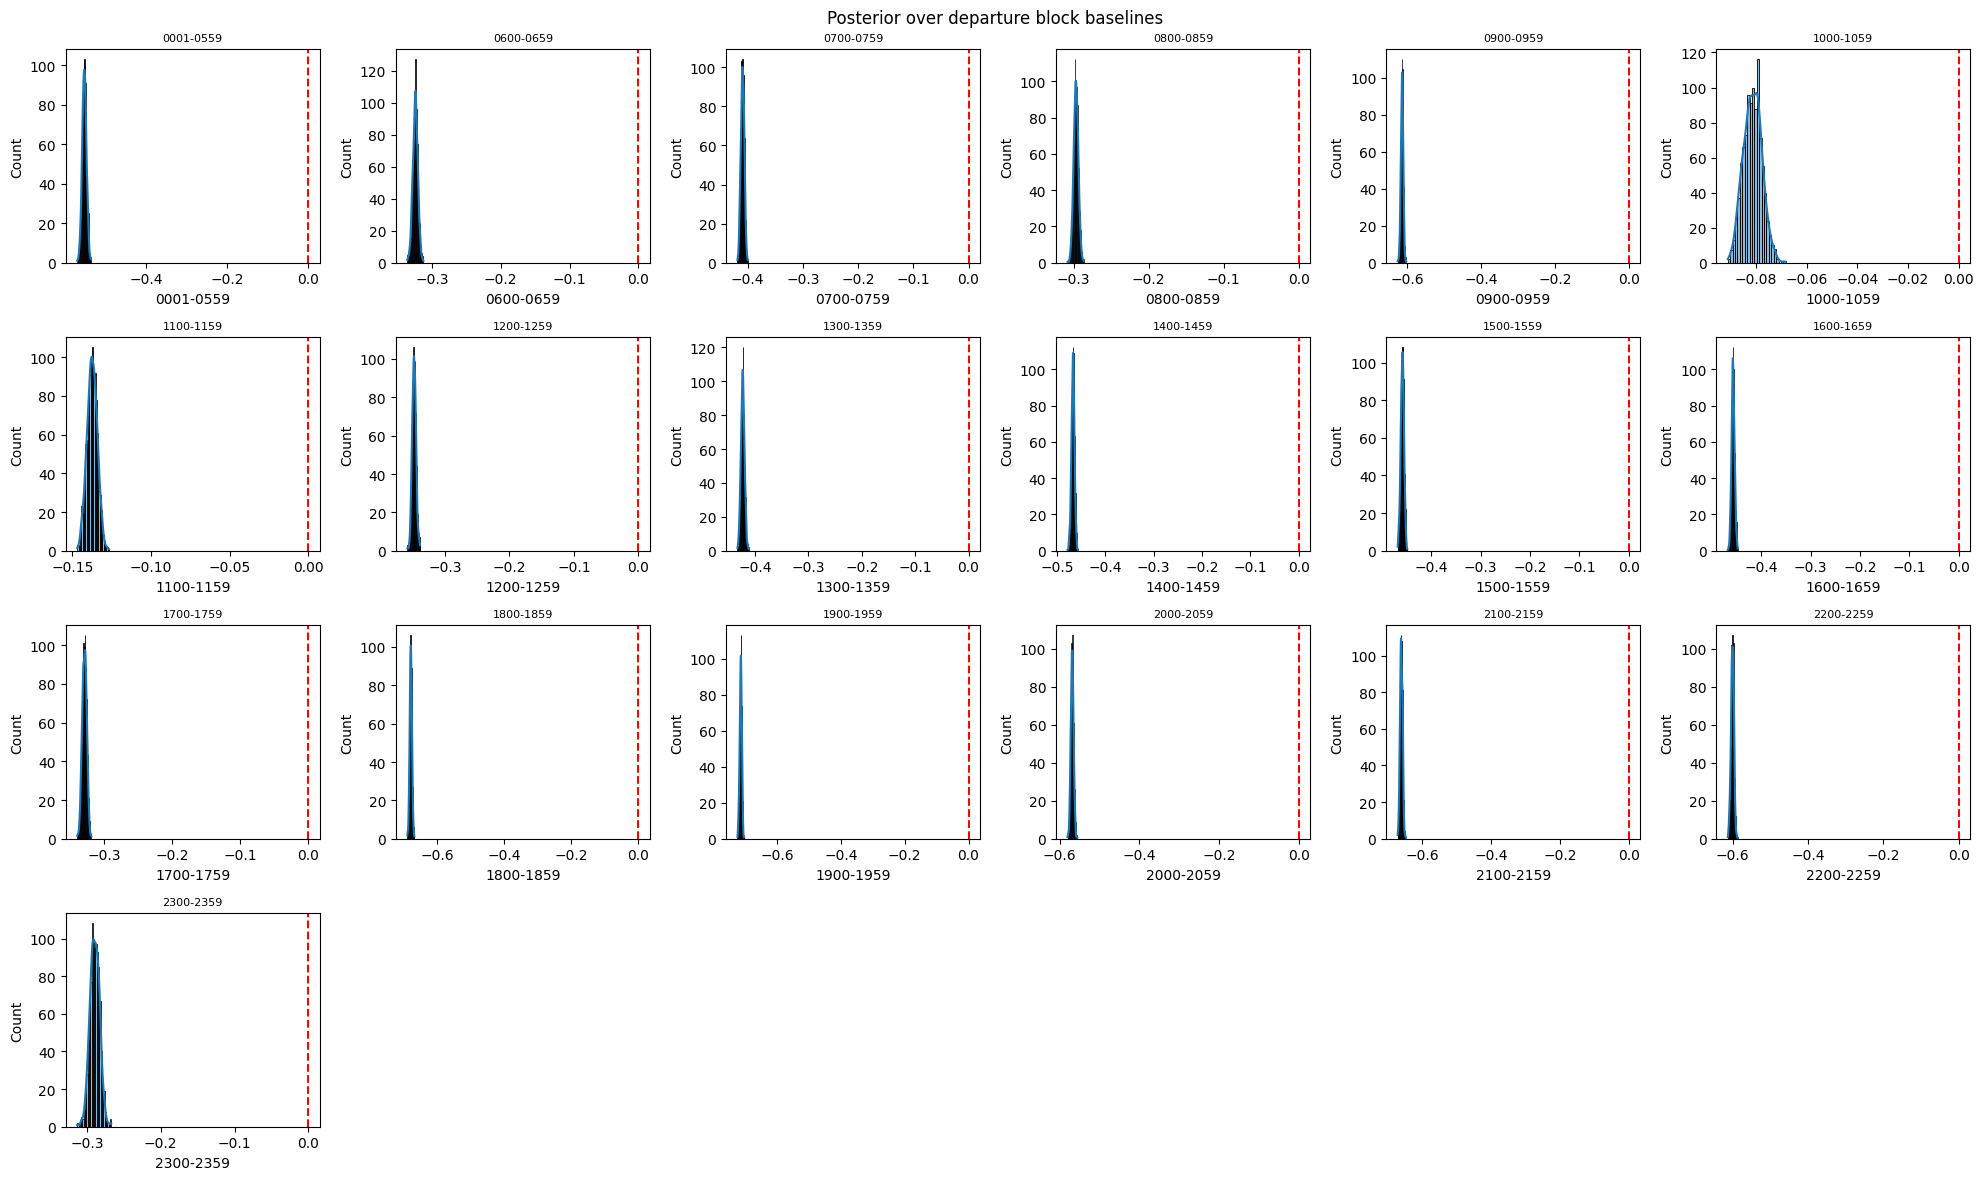

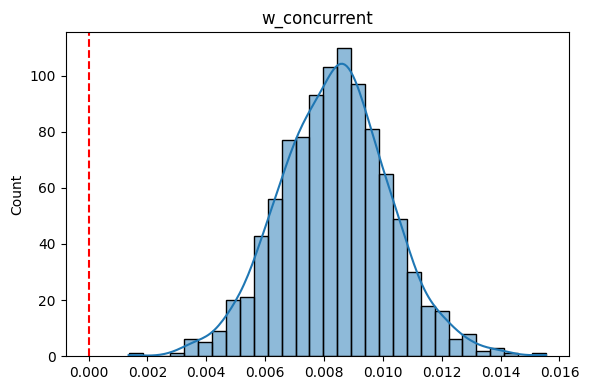

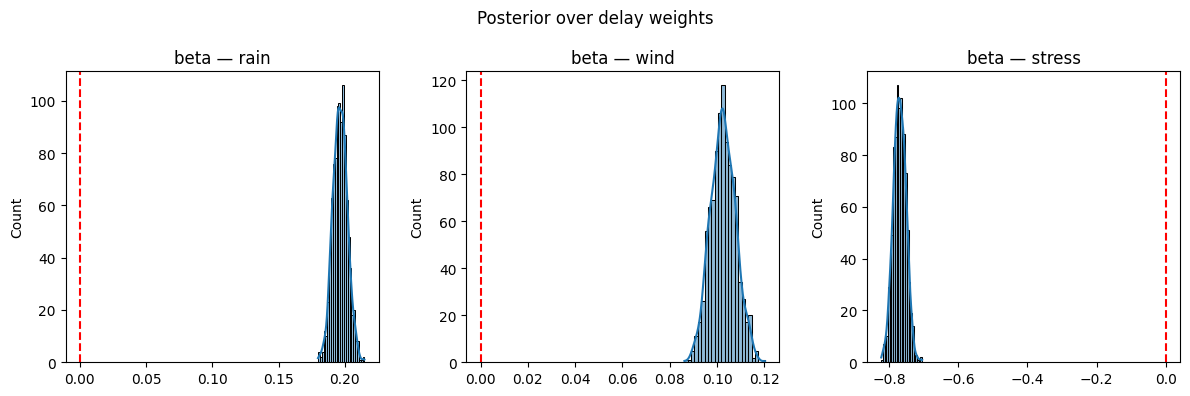

In [102]:
# ── carrier baselines ──
alpha_df = pd.DataFrame(alpha_carrier_samples, columns=carrier_categories3.tolist())

n_cols = len(carrier_categories3)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(alpha_df.columns):
    sns.histplot(alpha_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over carrier baselines")
plt.tight_layout()
plt.show()

# ── departure block baselines ──
gamma_df = pd.DataFrame(gamma_depblock_samples, columns=depblock_categories.tolist())

n_cols = len(depblock_categories)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(gamma_df.columns):
    sns.histplot(gamma_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over departure block baselines")
plt.tight_layout()
plt.show()

# ── w_concurrent ──
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.histplot(w_concurrent_samples, ax=ax, kde=True)
ax.axvline(0, color="red", linestyle="--")
ax.set_title("w_concurrent")
plt.tight_layout()
plt.show()

# ── delay weights — now separate scalars ──
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, samples, name in zip(axes, 
                              [beta_rain_samples, beta_wind_samples, beta_stress_samples],
                              ["rain", "wind", "stress"]):
    sns.histplot(samples, ax=ax, kde=True)
    ax.axvline(0, color="red", linestyle="--")
    ax.set_title(f"beta — {name}")
plt.suptitle("Posterior over delay weights")
plt.tight_layout()
plt.show()

In [103]:
# get posterior means
alpha_carrier_mean  = alpha_carrier_samples.mean(axis=0)   # (17,)
gamma_depblock_mean = gamma_depblock_samples.mean(axis=0)  # (19,)
w_concurrent_mean   = w_concurrent_samples.mean()           # scalar
beta_rain_mean      = beta_rain_samples.mean()              # scalar
beta_wind_mean      = beta_wind_samples.mean()              # scalar
beta_stress_mean    = beta_stress_samples.mean()            # scalar
bias_mean           = bias_samples.mean()                   # scalar

CHUNK = 10000
p_mean_list = []

for i in range(0, len(X_weather_test), CHUNK):
    X_w    = X_weather_test[i:i+CHUNK].numpy()
    c_idx  = carrier_idx_test[i:i+CHUNK].numpy()
    d_idx  = dep_block_idx_test[i:i+CHUNK].numpy()
    x_conc = X_conc_test[i:i+CHUNK].numpy()

    # stress = carrier baseline + depblock baseline + concurrent flights
    stress = (alpha_carrier_mean[c_idx] + 
              gamma_depblock_mean[d_idx] + 
              w_concurrent_mean * x_conc)

    logits = (beta_rain_mean   * X_w[:, 0] +
              beta_wind_mean   * X_w[:, 1] +
              beta_stress_mean * stress +
              bias_mean)

    p = torch.sigmoid(torch.tensor(logits, dtype=torch.float32)).numpy()
    p_mean_list.append(p)

p_mean = np.concatenate(p_mean_list)
y_pred = (p_mean > 0.5).astype(float)

In [104]:
y_test_np = y_test.numpy()

print("=== Test Evaluation ===")
print(f"Real delay rate:      {y_test_np.mean():.4f}")
print(f"Predicted delay rate: {y_pred.mean():.4f}")
print(f"Accuracy:  {accuracy_score(y_test_np, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_np, p_mean):.4f}")
print(classification_report(y_test_np, y_pred))

=== Test Evaluation ===
Real delay rate:      0.1891
Predicted delay rate: 0.0011
Accuracy:  0.8107
AUC-ROC:   0.5883
              precision    recall  f1-score   support

         0.0       0.81      1.00      0.90   1578509
         1.0       0.42      0.00      0.00    368210

    accuracy                           0.81   1946719
   macro avg       0.62      0.50      0.45   1946719
weighted avg       0.74      0.81      0.73   1946719



# 6. Fifth model

In [105]:
def model3_interaction(carrier_idx, X_concurrent, X_weather, X_dept, y):
    
    n_carriers = len(carrier_categories3)
    n_weather  = X_weather.shape[1]
    n_dept     = X_dept.shape[1]
    n_direct   = n_weather + n_dept + 1

    # hyperpriors on carrier baselines
    mu_alpha    = pyro.sample("mu_alpha",    dist.Normal(0., 1.))
    sigma_alpha = pyro.sample("sigma_alpha", dist.HalfNormal(1.))

    # carrier baselines
    alpha_carrier = pyro.sample("alpha_carrier",
                                dist.Normal(mu_alpha * torch.ones(n_carriers),
                                           sigma_alpha * torch.ones(n_carriers)).to_event(1))

    # stress parameters
    w_concurrent = pyro.sample("w_concurrent", dist.Normal(0., 1.))
    sigma_stress = pyro.sample("sigma_stress", dist.HalfNormal(1.0))

    # delay parameters
    beta_rain        = pyro.sample("beta_rain",        dist.Normal(0., 1.))
    beta_wind        = pyro.sample("beta_wind",        dist.Normal(0., 1.))
    beta_stress      = pyro.sample("beta_stress",      dist.Normal(0., 1.))
    beta_rain_stress = pyro.sample("beta_rain_stress", dist.Normal(0., 1.))
    beta_wind_stress = pyro.sample("beta_wind_stress", dist.Normal(0., 1.))

    # departure block coefficients — direct effect
    beta_dept = pyro.sample("beta_dept", 
                            dist.Normal(torch.zeros(n_dept), 
                                       torch.ones(n_dept)).to_event(1))
    bias = pyro.sample("bias", dist.Normal(0., 1.))

    with pyro.plate("flights", X_weather.shape[0]):
        
        mu_stress = alpha_carrier[..., carrier_idx] + w_concurrent * X_concurrent
        stress = pyro.sample("stress", dist.Normal(mu_stress, sigma_stress))

        logits = (
            beta_rain        * X_weather[:, 0] +
            beta_wind        * X_weather[:, 1] +
            beta_stress      * stress +
            beta_rain_stress * X_weather[:, 0] * stress +  # rain × stress interaction
            beta_wind_stress * X_weather[:, 1] * stress +  # wind × stress interaction
            (X_dept * beta_dept[..., :n_dept]).sum(dim=-1) +
            bias
        )

        obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    return obs

In [106]:
pyro.clear_param_store()
torch.manual_seed(42)
pyro.set_rng_seed(42)

guide_interaction = AutoDiagonalNormal(model3_interaction)
optimizer = ClippedAdam({"lr": 0.001})
svi = SVI(model3_interaction, guide_interaction, optimizer, loss=Trace_ELBO(num_particles=1))

losses_interaction = []
for step in range(5000):
    loss = svi.step(carrier_idx_train, X_conc_train, X_weather_train, X_dept_train, y_train)
    losses_interaction.append(loss)
    if step % 1000 == 0:
        print(f"[{step}] loss: {loss:.1f}")

[0] loss: 873565.5
[1000] loss: 248801.8
[2000] loss: 221786.1
[3000] loss: 213116.1
[4000] loss: 211907.1


In [108]:
# extract posteriors
predictive_int = Predictive(model3_interaction, guide=guide_interaction, num_samples=1000)
samples_int = predictive_int(carrier_idx_train, X_conc_train, X_weather_train, X_dept_train, None)

# extract samples
alpha_carrier_samples  = samples_int["alpha_carrier"].detach().squeeze(1).numpy()   # (1000, 17)
w_concurrent_samples   = samples_int["w_concurrent"].detach().squeeze(1).numpy()    # (1000,)
beta_rain_samples      = samples_int["beta_rain"].detach().squeeze(1).numpy()       # (1000,)
beta_wind_samples      = samples_int["beta_wind"].detach().squeeze(1).numpy()       # (1000,)
beta_stress_samples    = samples_int["beta_stress"].detach().squeeze(1).numpy()     # (1000,)
beta_rain_stress_samples = samples_int["beta_rain_stress"].detach().squeeze(1).numpy()  # (1000,)
beta_wind_stress_samples = samples_int["beta_wind_stress"].detach().squeeze(1).numpy()  # (1000,)
beta_dept_samples      = samples_int["beta_dept"].detach().squeeze(1).numpy()       # (1000, 18)
bias_samples           = samples_int["bias"].detach().squeeze(1).numpy()            # (1000,)

# print summaries
print("=== Stress parameters ===")
print(f"w_concurrent:   {w_concurrent_samples.mean():.4f} ± {w_concurrent_samples.std():.4f}")

print("\n=== Delay parameters ===")
print(f"beta_rain:        {beta_rain_samples.mean():.4f} ± {beta_rain_samples.std():.4f}")
print(f"beta_wind:        {beta_wind_samples.mean():.4f} ± {beta_wind_samples.std():.4f}")
print(f"beta_stress:      {beta_stress_samples.mean():.4f} ± {beta_stress_samples.std():.4f}")
print(f"beta_rain_stress: {beta_rain_stress_samples.mean():.4f} ± {beta_rain_stress_samples.std():.4f}")
print(f"beta_wind_stress: {beta_wind_stress_samples.mean():.4f} ± {beta_wind_stress_samples.std():.4f}")
print(f"bias:             {bias_samples.mean():.4f} ± {bias_samples.std():.4f}")

=== Stress parameters ===
w_concurrent:   0.3465 ± 0.0018

=== Delay parameters ===
beta_rain:        0.2050 ± 0.0057
beta_wind:        0.0931 ± 0.0056
beta_stress:      -0.0409 ± 0.0128
beta_rain_stress: 0.0046 ± 0.0092
beta_wind_stress: 0.0306 ± 0.0105
bias:             -1.9595 ± 0.0078


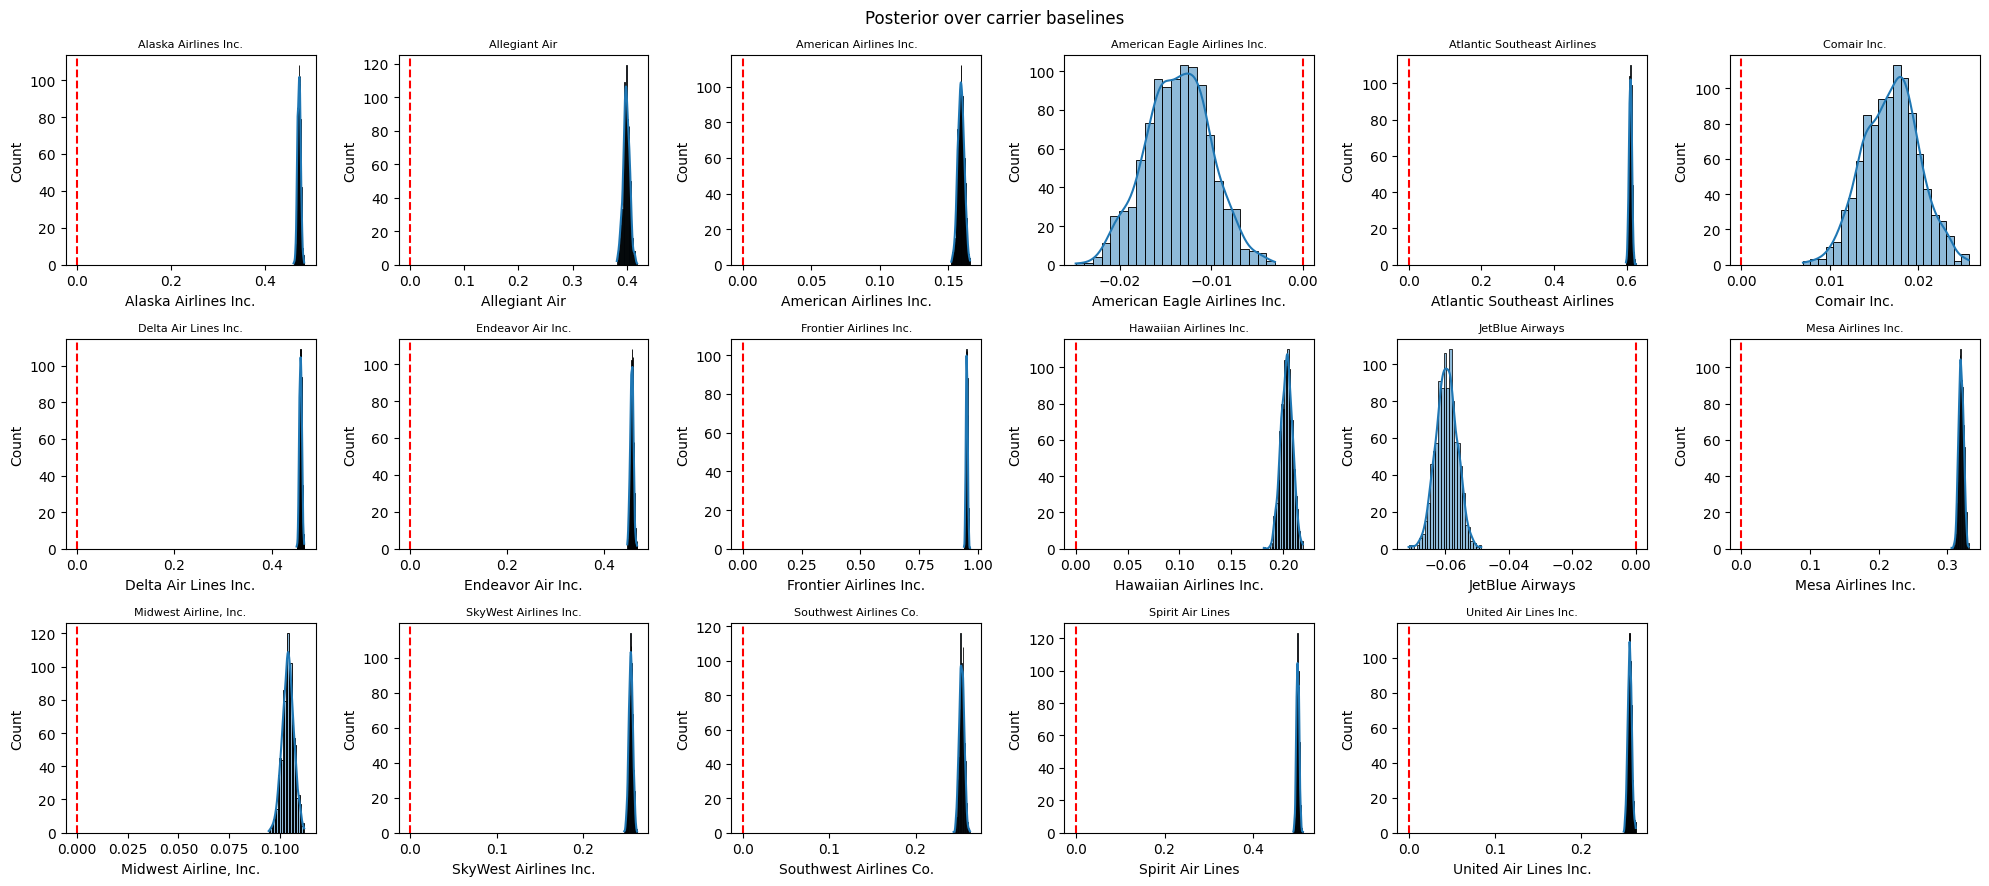

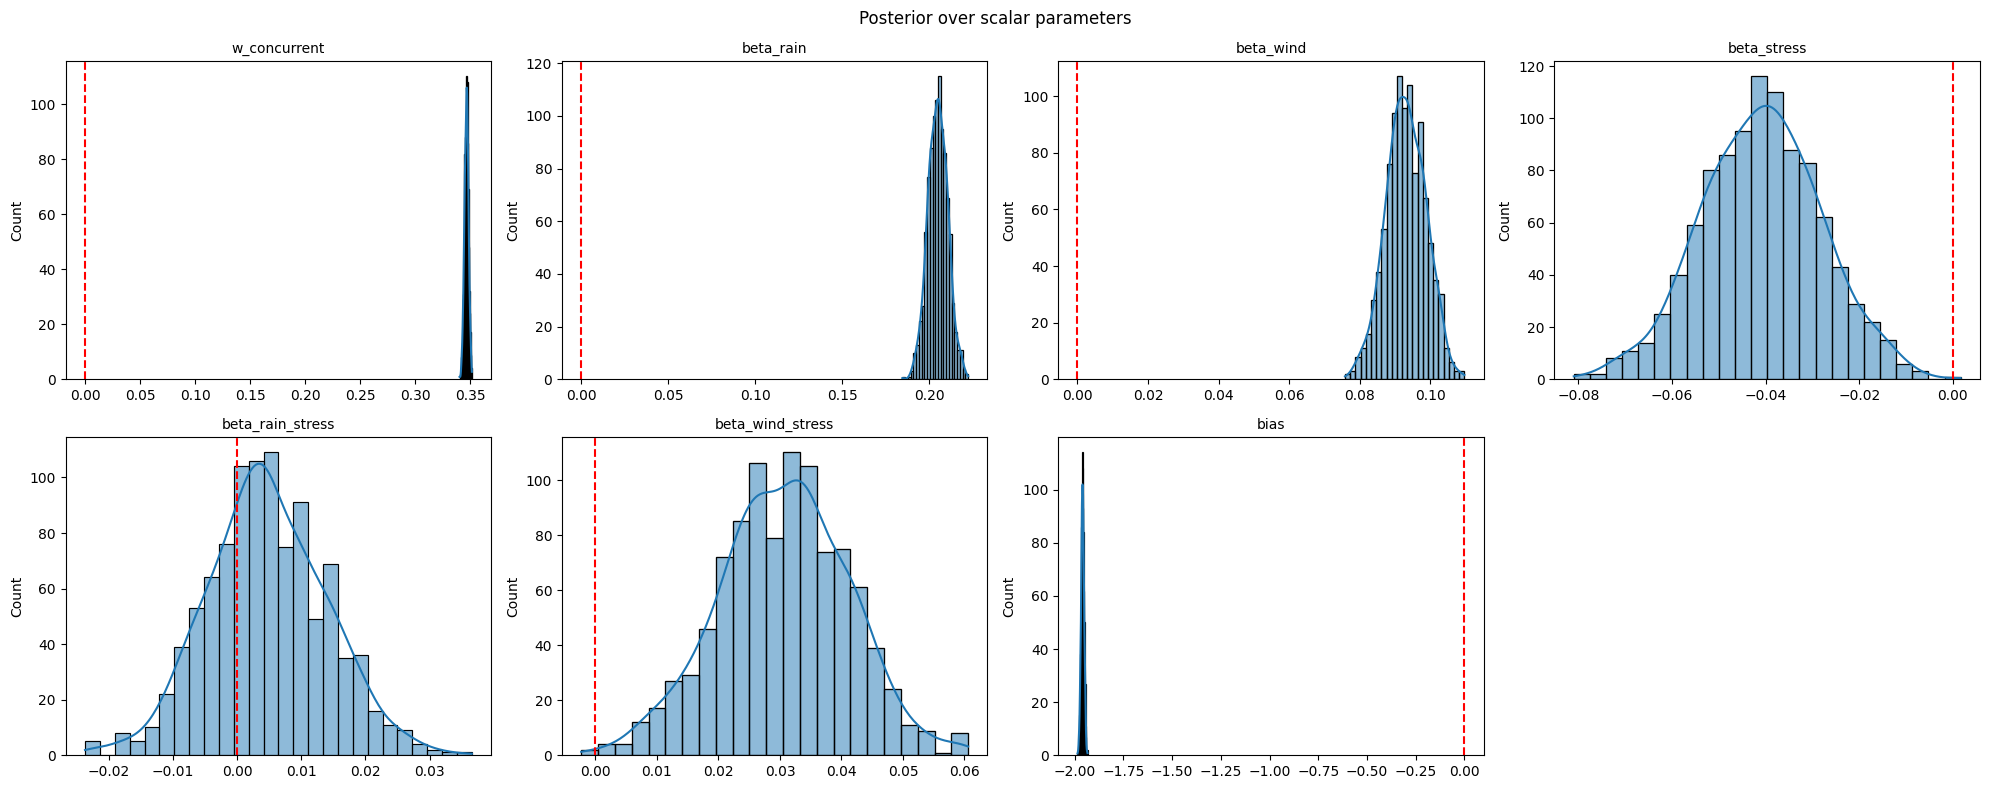

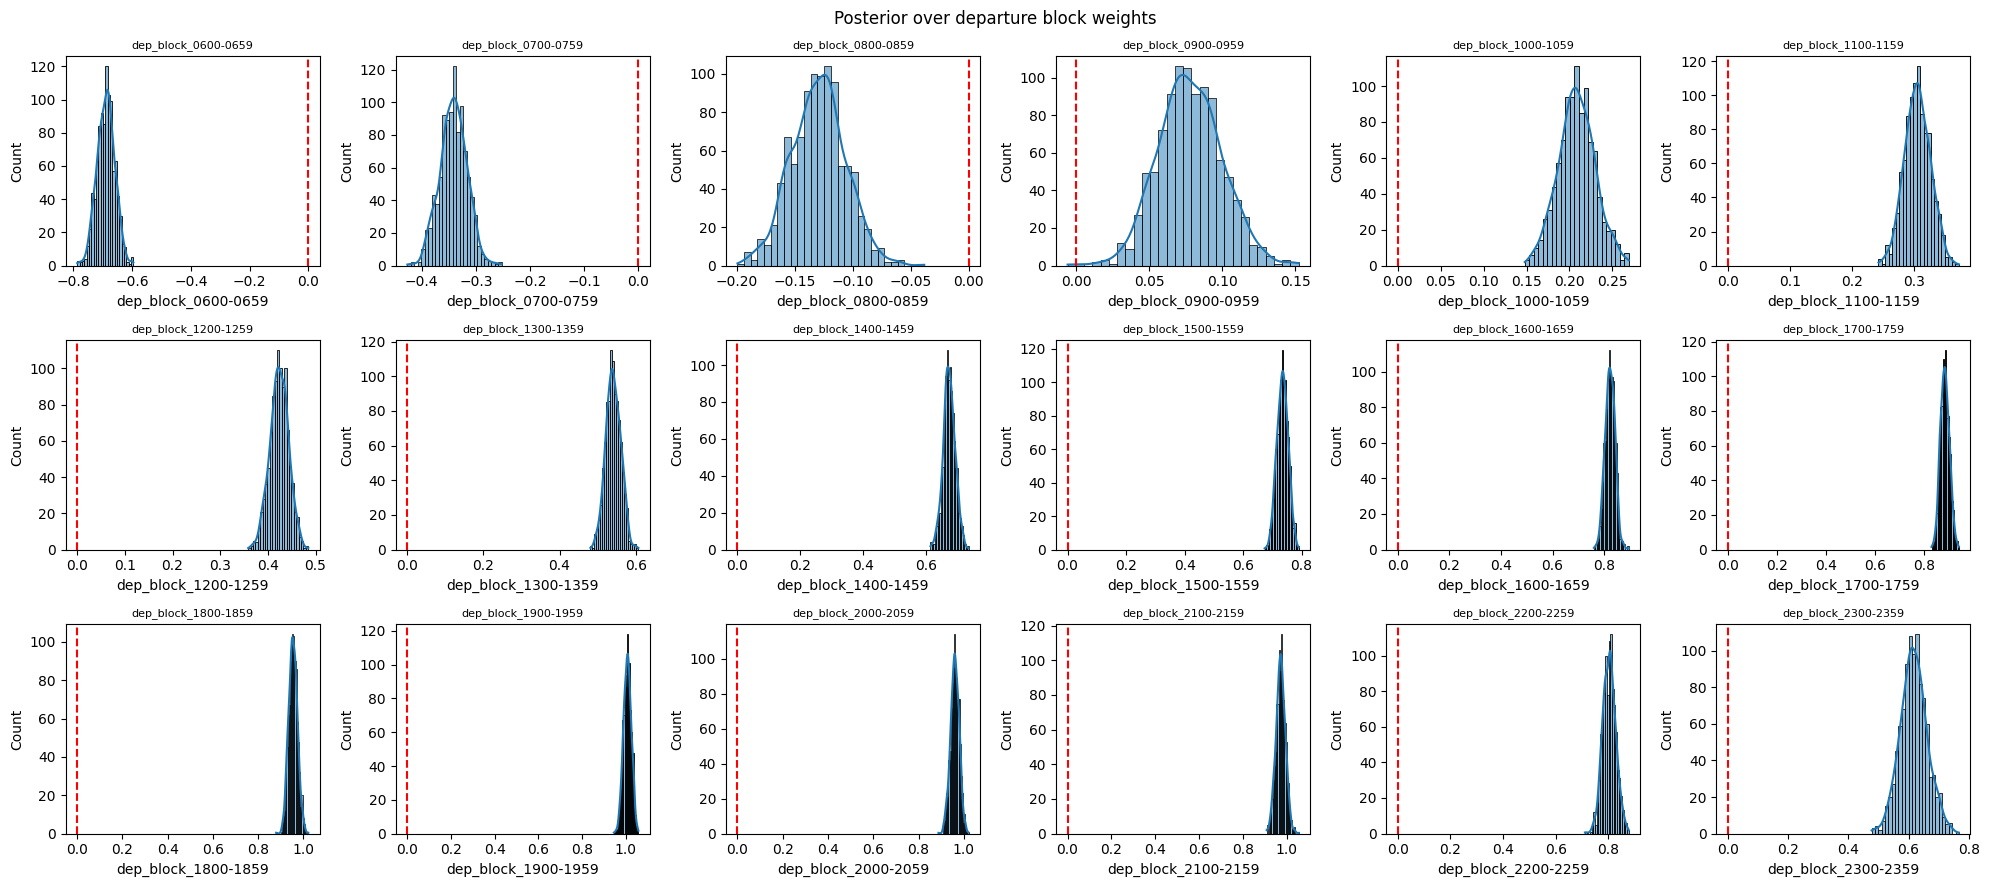

In [109]:
# ── carrier baselines ──
alpha_df = pd.DataFrame(alpha_carrier_samples, columns=carrier_categories3.tolist())
n_cols = len(carrier_categories3)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(alpha_df.columns):
    sns.histplot(alpha_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over carrier baselines")
plt.tight_layout()
plt.show()

# ── scalar delay weights ──
scalar_params = {
    "w_concurrent":   w_concurrent_samples,
    "beta_rain":      beta_rain_samples,
    "beta_wind":      beta_wind_samples,
    "beta_stress":    beta_stress_samples,
    "beta_rain_stress": beta_rain_stress_samples,
    "beta_wind_stress": beta_wind_stress_samples,
    "bias":           bias_samples
}

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, (name, samples) in enumerate(scalar_params.items()):
    sns.histplot(samples, ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(name, fontsize=10)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over scalar parameters")
plt.tight_layout()
plt.show()

# ── departure block weights ──
beta_dept_df = pd.DataFrame(beta_dept_samples, columns=dpt_columns_model)
n_cols = len(dpt_columns_model)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(beta_dept_df.columns):
    sns.histplot(beta_dept_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over departure block weights")
plt.tight_layout()
plt.show()

In [110]:
# get posterior means
alpha_carrier_mean       = alpha_carrier_samples.mean(axis=0)      # (17,)
w_concurrent_mean        = w_concurrent_samples.mean()              # scalar
beta_rain_mean           = beta_rain_samples.mean()                 # scalar
beta_wind_mean           = beta_wind_samples.mean()                 # scalar
beta_stress_mean         = beta_stress_samples.mean()               # scalar
beta_rain_stress_mean    = beta_rain_stress_samples.mean()          # scalar
beta_wind_stress_mean    = beta_wind_stress_samples.mean()          # scalar
beta_dept_mean           = beta_dept_samples.mean(axis=0)           # (18,)
bias_mean                = bias_samples.mean()                      # scalar

CHUNK = 10000
p_mean_list = []

for i in range(0, len(X_weather_test), CHUNK):
    X_w    = X_weather_test[i:i+CHUNK].numpy()
    X_d    = X_dept_test[i:i+CHUNK].numpy()
    c_idx  = carrier_idx_test[i:i+CHUNK].numpy()
    x_conc = X_conc_test[i:i+CHUNK].numpy()

    # compute stress
    stress = alpha_carrier_mean[c_idx] + w_concurrent_mean * x_conc

    # compute logits with interaction terms
    logits = (
        beta_rain_mean        * X_w[:, 0] +
        beta_wind_mean        * X_w[:, 1] +
        beta_stress_mean      * stress +
        beta_rain_stress_mean * X_w[:, 0] * stress +  # rain × stress
        beta_wind_stress_mean * X_w[:, 1] * stress +  # wind × stress
        (X_d * beta_dept_mean).sum(axis=1) +
        bias_mean
    )

    p = torch.sigmoid(torch.tensor(logits, dtype=torch.float32)).numpy()
    p_mean_list.append(p)

p_mean = np.concatenate(p_mean_list)
y_pred = (p_mean > 0.5).astype(float)

# evaluate
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

y_test_np = y_test.numpy()

print("=== Test Evaluation Model 3 Interaction ===")
print(f"Real delay rate:      {y_test_np.mean():.4f}")
print(f"Predicted delay rate: {y_pred.mean():.4f}")
print(f"Accuracy:  {accuracy_score(y_test_np, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_np, p_mean):.4f}")
print(classification_report(y_test_np, y_pred))

# optimal threshold
from sklearn.metrics import f1_score
thresholds = np.arange(0.10, 0.35, 0.01)
f1_scores  = [f1_score(y_test_np, (p_mean > t).astype(float)) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_best = (p_mean > best_threshold).astype(float)
print(f"\n=== Optimal Threshold: {best_threshold:.2f} ===")
print(classification_report(y_test_np, y_pred_best))

=== Test Evaluation Model 3 Interaction ===
Real delay rate:      0.1891
Predicted delay rate: 0.0034
Accuracy:  0.8108
AUC-ROC:   0.6465
              precision    recall  f1-score   support

         0.0       0.81      1.00      0.90   1578509
         1.0       0.48      0.01      0.02    368210

    accuracy                           0.81   1946719
   macro avg       0.65      0.50      0.46   1946719
weighted avg       0.75      0.81      0.73   1946719


=== Optimal Threshold: 0.19 ===
              precision    recall  f1-score   support

         0.0       0.88      0.53      0.66   1578509
         1.0       0.25      0.68      0.37    368210

    accuracy                           0.56   1946719
   macro avg       0.56      0.60      0.51   1946719
weighted avg       0.76      0.56      0.60   1946719



# 7. Sixth model

In [158]:
def model6(carrier_idx, X_stress_cont, X_weather, X_dept, y):
    
    n_carriers   = len(carrier_categories3)
    n_stress     = X_stress_cont.shape[1]  # 4
    n_weather    = X_weather.shape[1]      # 2
    n_dept       = X_dept.shape[1]         # 18

    # hyperpriors on carrier baselines
    mu_alpha    = pyro.sample("mu_alpha",    dist.Normal(0., 1.))
    sigma_alpha = pyro.sample("sigma_alpha", dist.HalfNormal(1.))

    # carrier baselines
    alpha_carrier = pyro.sample("alpha_carrier",
                                dist.Normal(mu_alpha * torch.ones(n_carriers),
                                           sigma_alpha * torch.ones(n_carriers)).to_event(1))

    # stress weights — one per continuous stress variable
    w_stress = pyro.sample("w_stress", 
                           dist.Normal(torch.zeros(n_stress), 
                                      torch.ones(n_stress)).to_event(1))
    sigma_stress = pyro.sample("sigma_stress", dist.HalfNormal(1.0))

    # delay parameters
    beta_rain   = pyro.sample("beta_rain",   dist.Normal(0., 1.))
    beta_wind   = pyro.sample("beta_wind",   dist.Normal(0., 1.))
    beta_stress = pyro.sample("beta_stress", dist.Normal(0., 1.))
    beta_dept   = pyro.sample("beta_dept",   
                              dist.Normal(torch.zeros(n_dept), 
                                         torch.ones(n_dept)).to_event(1))
    bias = pyro.sample("bias", dist.Normal(0., 1.))

    with pyro.plate("flights", X_weather.shape[0]):
        
        # stress mean — carrier baseline + weighted continuous variables
        mu_stress = (alpha_carrier[..., carrier_idx] + 
                     (X_stress_cont * w_stress[..., :n_stress]).sum(dim=-1))
        
        stress = pyro.sample("stress", dist.Normal(mu_stress, sigma_stress))

        logits = (
            beta_rain   * X_weather[:, 0] +
            beta_wind   * X_weather[:, 1] +
            beta_stress * stress +
            (X_dept * beta_dept[..., :n_dept]).sum(dim=-1) +
            bias
        )

        obs = pyro.sample("obs", dist.Bernoulli(logits=logits), obs=y)

    return obs

In [159]:
pyro.clear_param_store()
# torch.manual_seed(42)
# pyro.set_rng_seed(42)

guide6 = AutoDiagonalNormal(model6)
optimizer = ClippedAdam({"lr": 0.001})
svi = SVI(model6, guide6, optimizer, loss=Trace_ELBO(num_particles=1))

losses6 = []
for step in range(5000):
    loss = svi.step(carrier_idx_train, X_stress_cont_new, 
                    X_weather_train, X_dept_train, y_train)
    losses6.append(loss)
    if step % 1000 == 0:
        print(f"[{step}] loss: {loss:.1f}")

[0] loss: 912893.2
[1000] loss: 247704.7
[2000] loss: 226713.3
[3000] loss: 216370.2
[4000] loss: 212491.6


In [161]:
predictive6 = Predictive(model6, guide=guide6, num_samples=1000)
samples6 = predictive6(carrier_idx_train, X_stress_cont_new,
                       X_weather_train, X_dept_train, None)

# extract samples
alpha_carrier_samples = samples6["alpha_carrier"].detach().squeeze(1).numpy()  # (1000, 17)
w_stress_samples      = samples6["w_stress"].detach().squeeze(1).numpy()        # (1000, 4)
beta_rain_samples     = samples6["beta_rain"].detach().squeeze(1).numpy()       # (1000,)
beta_wind_samples     = samples6["beta_wind"].detach().squeeze(1).numpy()       # (1000,)
beta_stress_samples   = samples6["beta_stress"].detach().squeeze(1).numpy()     # (1000,)
beta_dept_samples     = samples6["beta_dept"].detach().squeeze(1).numpy()       # (1000, 18)
bias_samples          = samples6["bias"].detach().squeeze(1).numpy()            # (1000,)

# print summaries
print("=== Stress weights ===")
for i, col in enumerate(stress_cols_new):
    print(f"  w_{col}: {w_stress_samples[:, i].mean():.4f} ± {w_stress_samples[:, i].std():.4f}")

print("\n=== Carrier baselines ===")
for i, carrier in enumerate(carrier_categories3):
    print(f"  {carrier}: {alpha_carrier_samples[:, i].mean():.4f} ± {alpha_carrier_samples[:, i].std():.4f}")

print("\n=== Delay parameters ===")
print(f"beta_rain:   {beta_rain_samples.mean():.4f} ± {beta_rain_samples.std():.4f}")
print(f"beta_wind:   {beta_wind_samples.mean():.4f} ± {beta_wind_samples.std():.4f}")
print(f"beta_stress: {beta_stress_samples.mean():.4f} ± {beta_stress_samples.std():.4f}")
print(f"bias:        {bias_samples.mean():.4f} ± {bias_samples.std():.4f}")

=== Stress weights ===
  w_PREV_AIRPORT_DELAY_RATE: -0.0295 ± 0.0019
  w_SEGMENT_NUMBER: -0.0402 ± 0.0024
  w_CONCURRENT_FLIGHTS: -0.3708 ± 0.0023
  w_GROUND_SERV_PER_PASS: 0.0947 ± 0.0037

=== Carrier baselines ===
  Alaska Airlines Inc.: 0.5862 ± 0.0060
  Allegiant Air: 0.2537 ± 0.0073
  American Airlines Inc.: 0.5533 ± 0.0054
  American Eagle Airlines Inc.: 0.1973 ± 0.0055
  Atlantic Southeast Airlines: 0.6342 ± 0.0084
  Comair Inc.: 0.5202 ± 0.0063
  Delta Air Lines Inc.: 0.2214 ± 0.0034
  Endeavor Air Inc.: 0.3530 ± 0.0059
  Frontier Airlines Inc.: 0.4428 ± 0.0127
  Hawaiian Airlines Inc.: 0.7397 ± 0.0108
  JetBlue Airways: 0.0935 ± 0.0040
  Mesa Airlines Inc.: 0.6162 ± 0.0061
  Midwest Airline, Inc.: 0.3872 ± 0.0033
  SkyWest Airlines Inc.: 0.5137 ± 0.0051
  Southwest Airlines Co.: 0.3311 ± 0.0053
  Spirit Air Lines: 0.5537 ± 0.0041
  United Air Lines Inc.: 0.0825 ± 0.0098

=== Delay parameters ===
beta_rain:   0.2062 ± 0.0050
beta_wind:   0.1003 ± 0.0055
beta_stress: -0.0680 ± 0

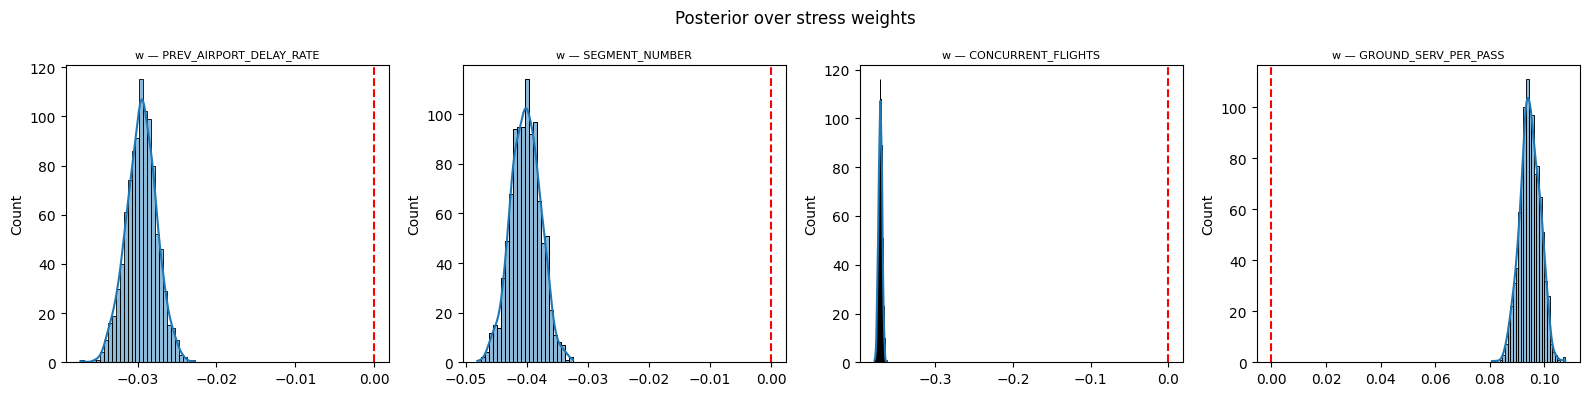

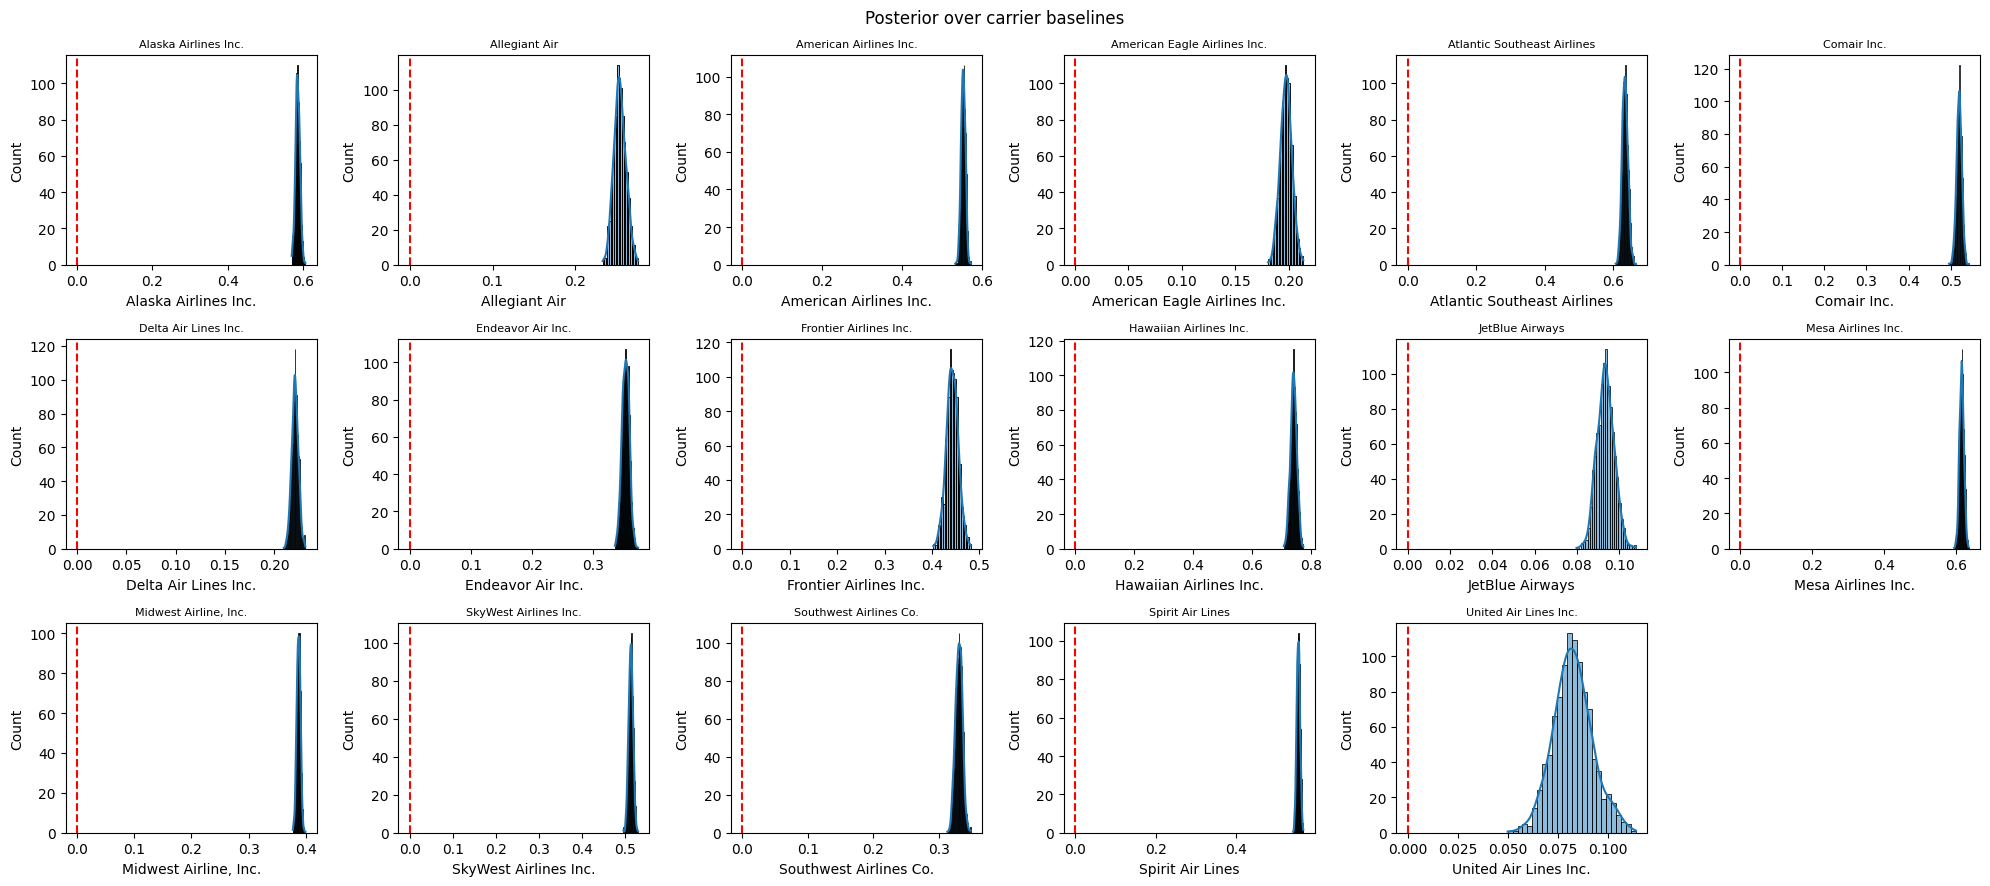

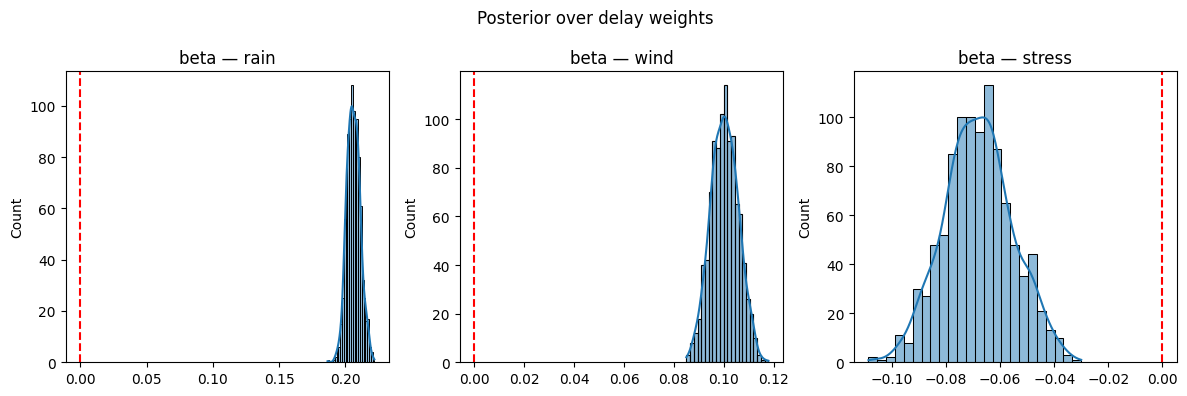

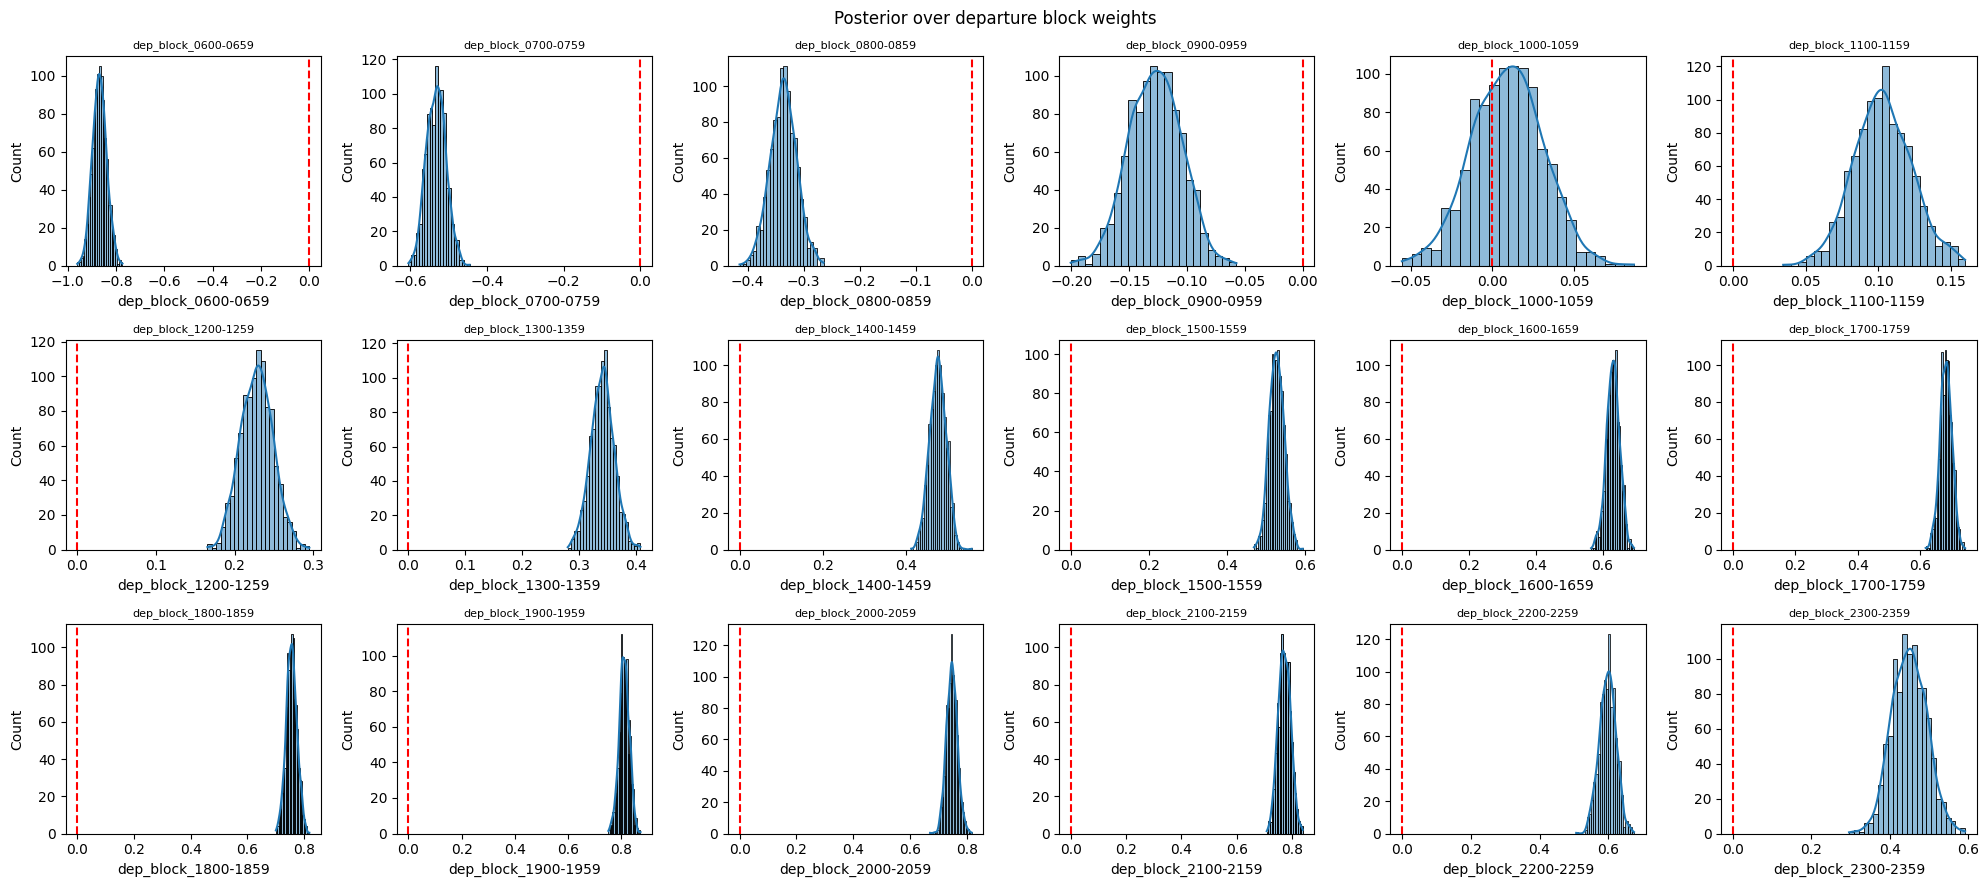

In [162]:
# ── stress weights ──
fig, axes = plt.subplots(1, len(stress_cols_new), figsize=(16, 4))
for i, col in enumerate(stress_cols_new):
    sns.histplot(w_stress_samples[:, i], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(f"w — {col}", fontsize=8)
plt.suptitle("Posterior over stress weights")
plt.tight_layout()
plt.show()

# ── carrier baselines ──
alpha_df = pd.DataFrame(alpha_carrier_samples, columns=carrier_categories3.tolist())
n_cols = len(carrier_categories3)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(alpha_df.columns):
    sns.histplot(alpha_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over carrier baselines")
plt.tight_layout()
plt.show()

# ── delay weights ──
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, samples, name in zip(axes,
                              [beta_rain_samples, beta_wind_samples, beta_stress_samples],
                              ["rain", "wind", "stress"]):
    sns.histplot(samples, ax=ax, kde=True)
    ax.axvline(0, color="red", linestyle="--")
    ax.set_title(f"beta — {name}")
plt.suptitle("Posterior over delay weights")
plt.tight_layout()
plt.show()

# ── departure block weights ──
beta_dept_df = pd.DataFrame(beta_dept_samples, columns=dpt_columns_model)
n_cols = len(dpt_columns_model)
n_rows = (n_cols + 5) // 6
fig, axes = plt.subplots(n_rows, 6, figsize=(20, n_rows*3))
axes = axes.flatten()
for i, col in enumerate(beta_dept_df.columns):
    sns.histplot(beta_dept_df[col], ax=axes[i], kde=True)
    axes[i].axvline(0, color="red", linestyle="--")
    axes[i].set_title(col, fontsize=8)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Posterior over departure block weights")
plt.tight_layout()
plt.show()